[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter3_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 3: Structural VAR and local projections

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Recursive identification: the Christiano–Eichenbaum–Evans monetary VAR; Kilian (2009) on oil.
- Long-run identification: Blanchard and Quah (1989).
- Sign restrictions and set identification: the rotation set; Uhlig (2005).
- External instruments: Gertler and Karadi (2015); inference with the moving-block bootstrap.
- Local projections: LP against VAR (simulation and data), LP-IV, state-dependent multipliers (Ramey and Zubairy 2018).
- Romania: a VAR with a euro-area block and local projections on ECB policy shocks.
- Public files are downloaded once per session (Ramey's replication files, the EIA bulk file of about 25 MB); bootstrap replications are reduced here to keep the run short.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_3'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- VAR: `var_ols`, `companion`, `max_root`, `ma_coefs`, `irf`, `fevd`, `simulate_var`.
- Inference: `bootstrap_var` (residual or wild, optional Kilian bias correction), `kilian_bias`, `shrink_bias`, `bands`.
- Local projections: `nw_se`, `lp`, `tsls`, `lp_iv`, `lags_of`; data helpers `get_bytes`, `zip_member`, `read_ecb`.

In [5]:
import io
import zipfile
import urllib.error
SEED = 2026
RAMEY_MON = 'https://econweb.ucsd.edu/~vramey/research/Ramey_HOM_monetary.zip'
RAMEY_RZ = 'https://econweb.ucsd.edu/~vramey/research/Ramey_Zubairy_replication_codes.zip'
EIA_INTL = 'https://api.eia.gov/bulk/INTL.zip'
EIA_PROD = 'INTL.57-1-WORL-TBPD.M'
EIA_MER9 = 'https://www.eia.gov/totalenergy/data/browser/csv.php?tbl=T09.01'
EA_Y1 = ('YC', 'B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y')
JK_ECB = 'https://raw.githubusercontent.com/marekjarocinski/jkshocks_update_ecb/main/shocks_ecb_mpd_me_m.csv'
RO_IP = ('sts_inpr_m', 'M.PRD.B-D.SCA.I21.RO')
EA_IP = ('sts_inpr_m', 'M.PRD.B-D.SCA.I21.EA20')
RO_HICP = ('prc_hicp_minr', 'M.I25.TOTAL.RO')
EA_HICP = ('prc_hicp_minr', 'M.I25.TOTAL.EA')
RO_R3M = ('irt_st_m', 'M.IRT_M3.RO')
EA_R3M = ('irt_st_m', 'M.IRT_M3.EA')
RO_START = '2005-08-01'
CEE = {'vars': ['lip', 'unemp', 'lcpi', 'lpcom', 'ffr', 'lnbr', 'ltr', 'lm1'], 'p': 12, 'start': '1965-01-01', 'end': '1995-06-01', 'H': 48, 'shock': 'ffr'}
KIL = {'p': 24, 'start': '1973-01-01', 'end': '2007-12-01', 'H': 18}
BQ = {'p': 8, 'start': '1948-04-01', 'end': '1987-10-01', 'brk': '1974-01-01', 'H': 40}
UHL = {'vars': ['lip', 'lcpi', 'lpcom', 'ffr', 'lnbr', 'ltr'], 'p': 12, 'start': '1965-01-01', 'end': '2003-12-01', 'K': 5, 'H': 60}
GK = {'vars': ['gs1', 'lip', 'lcpi', 'ebp'], 'p': 12, 'start': '1979-07-01', 'end': '2012-06-01', 'zstart': '1991-01-01', 'H': 48}
LPGK = {'p': 2, 'start': '1990-01-01', 'end': '2012-06-01', 'H': 48}
RZ = {'p': 4, 'H': 20, 'thr': 6.5, 'start': 1889.0}
RO = {'p': 2, 'H': 36, 'end': '2026-07-01'}
NBOOT = 500
RO_VARS = ['ip_ea', 'p_ea', 'r_ea', 'ip_ro', 'p_ro', 'r_ro', 'fx']
PSI = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 0.8, 0.6, 0.4, 0.3, 0.2, 0.1])
KIL_SIGN = np.diag([-1.0, 1.0, 1.0])
_FILES = {}


def read_ecb(flow, key, start=None):
    """One series from the ECB Data Portal (public SDMX REST API, CSV), e.g. the monthly USD/EUR reference rate:
        read_ecb('EXR', 'M.USD.EUR.SP00.A')
    or the euro-area HICP annual rate of change: read_ecb('ICP', 'M.U2.N.000000.4.ANR')."""
    url = (f'https://data-api.ecb.europa.eu/service/data/{flow}/{key}?format=csvdata'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('ecb', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{flow}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def get_bytes(url):
    """Download a public file once per session (no key); optional local cache folder ATS_CACHE."""
    import hashlib
    import time
    if url in _FILES:
        return _FILES[url]
    cache = os.environ.get('ATS_CACHE')
    path = os.path.join(cache, hashlib.md5(url.encode()).hexdigest()) if cache else None
    if path and os.path.exists(path):
        _FILES[url] = open(path, 'rb').read()
        return _FILES[url]
    for attempt in range(5):
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (ATS course)'})
            _FILES[url] = urllib.request.urlopen(req, timeout=300).read()
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 4:
                raise
            time.sleep(10 * (attempt + 1))
    if path:
        os.makedirs(cache, exist_ok=True)
        open(path, 'wb').write(_FILES[url])
    return _FILES[url]


def zip_member(url, name):
    """One file from a public zip archive."""
    z = zipfile.ZipFile(io.BytesIO(get_bytes(url)))
    m = [f for f in z.namelist() if f.endswith(name)][0]
    return z.read(m)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def lagmat(Y, p):
    """Regressor matrix [Y_{t-1}, ..., Y_{t-p}] for t = p..T-1 (rows), and the left-hand side Y_t."""
    Y = np.asarray(Y, float)
    T = len(Y)
    X = np.hstack([Y[p - j - 1:T - j - 1] for j in range(p)])
    return Y[p:], X


def var_ols(Y, p, const=True, exog=None):
    """OLS of a VAR(p) with optional constant and exogenous regressors (aligned with Y). Returns a dict with the lag
    matrices A (p x n x n), the deterministic coefficients, residuals U (T-p x n) and Sigma = U'U/(T - p - k)."""
    Yt, X = lagmat(Y, p)
    n = Yt.shape[1]
    D = []
    if const:
        D.append(np.ones((len(Yt), 1)))
    if exog is not None:
        D.append(np.asarray(exog, float)[p:])
    Xf = np.hstack([X] + D) if D else X
    B = np.linalg.lstsq(Xf, Yt, rcond=None)[0]
    U = Yt - Xf @ B
    k = Xf.shape[1]
    A = np.stack([B[j * n:(j + 1) * n].T for j in range(p)])
    return dict(A=A, det=B[n * p:], U=U, Sigma=U.T @ U / (len(Yt) - k), Sigma_ml=U.T @ U / len(Yt), X=Xf, B=B,
                Y=np.asarray(Y, float), p=p, const=const, exog=exog)


def companion(A):
    p, n, _ = A.shape
    F = np.zeros((n * p, n * p))
    F[:n] = np.hstack(list(A))
    F[n:, :-n] = np.eye(n * (p - 1))
    return F


def max_root(A):
    return float(np.max(np.abs(np.linalg.eigvals(companion(A)))))


def ma_coefs(A, H):
    """Reduced-form MA coefficients Phi_0..Phi_H (Phi_0 = I)."""
    p, n, _ = A.shape
    Phi = np.zeros((H + 1, n, n))
    Phi[0] = np.eye(n)
    for h in range(1, H + 1):
        Phi[h] = sum(A[j] @ Phi[h - j - 1] for j in range(min(p, h)))
    return Phi


def irf(A, B0, H):
    """Structural impulse responses Theta_h = Phi_h B0 (H+1 x n x n): [h, response, shock]."""
    return np.einsum('hij,jk->hik', ma_coefs(A, H), B0)


def fevd(Theta):
    """Forecast error variance decomposition: share of shock k in the h-step error variance of variable i."""
    c = np.cumsum(Theta ** 2, axis=0)
    return c / c.sum(axis=2, keepdims=True)


def simulate_var(A, det, Xdet, U, Y0):
    """Recursive simulation of a VAR from initial values Y0 (p x n) with residuals U and deterministic terms."""
    p, n, _ = A.shape
    T = len(U)
    Y = np.zeros((T + p, n))
    Y[:p] = Y0
    for t in range(T):
        y = sum(A[j] @ Y[p + t - j - 1] for j in range(p)) + U[t]
        if Xdet is not None:
            y = y + Xdet[t] @ det
        Y[p + t] = y
    return Y


def bootstrap_var(m, ident, H, B=NBOOT, kind='residual', seed=SEED, bias=None):
    """Bootstrap distribution of structural responses. ident(A, Sigma, U) -> B0. kind: 'residual' (i.i.d. resampling
    of residuals) or 'wild' (recursive-design wild bootstrap, Rademacher weights; Goncalves and Kilian 2004).
    bias: optional bias of A (Kilian 1998) subtracted from each bootstrap estimate."""
    rng = np.random.default_rng(seed)
    A, U, p, Y = m['A'], m['U'], m['p'], m['Y']
    n = A.shape[1]
    Xdet = m['X'][:, n * p:] if m['X'].shape[1] > n * p else None
    det = m['det'] if Xdet is not None else None
    Uc = U - U.mean(axis=0)
    out = np.zeros((B, H + 1, n, n))
    Abar = np.zeros_like(A)
    for b in range(B):
        Ub = Uc[rng.integers(0, len(U), len(U))] if kind == 'residual' else U * rng.choice([-1.0, 1.0], (len(U), 1))
        s = rng.integers(0, len(Y) - p + 1)
        Yb = simulate_var(A, det, Xdet, Ub, Y[s:s + p])
        mb = var_ols(Yb, p, const=m['const'], exog=None if m['exog'] is None else m['exog'])
        Ab = mb['A']
        Abar += Ab / B
        if bias is not None:
            Ab = shrink_bias(Ab, bias)
        out[b] = irf(Ab, ident(Ab, mb['Sigma'], mb['U']), H)
    return out, Abar


def shrink_bias(A, bias):
    """Kilian (1998): subtract the bias, shrinking the correction until the corrected VAR is stationary."""
    d = 1.0
    while d > 0:
        Ac = A - d * bias
        if max_root(Ac) < 1:
            return Ac
        d -= 0.01
    return A


def kilian_bias(m, B=200, seed=SEED + 1):
    """Bootstrap estimate of the small-sample bias of the VAR slope coefficients (Kilian 1998, first stage)."""
    _, Abar = bootstrap_var(m, lambda A, S, U: np.eye(A.shape[1]), 0, B=B, seed=seed)
    return Abar - m['A']


def bands(draws, lev=(0.05, 0.95)):
    return np.quantile(draws, lev[0], axis=0), np.quantile(draws, lev[1], axis=0)


def chol(A, S, U):
    return np.linalg.cholesky(S)


def band_plot(ax, h, mid, lo, hi, color, label, lo2=None, hi2=None):
    """Point estimate with a shaded band (and an optional inner band)."""
    ax.fill_between(h, lo, hi, color=color, alpha=0.15, lw=0, label='_band')
    if lo2 is not None:
        ax.fill_between(h, lo2, hi2, color=color, alpha=0.28, lw=0, label='_band2')
    ax.plot(h, mid, color=color, lw=1.8, label=label)
    ax.axhline(0, color=st.DarkText, lw=0.6)


def patch(color, alpha=0.2):
    from matplotlib.patches import Patch
    return Patch(color=color, alpha=alpha)


def nw_se(X, e, L):
    """Newey-West (Bartlett) covariance of OLS coefficients with L lags."""
    XtXi = np.linalg.inv(X.T @ X)
    g = X * e[:, None]
    S = g.T @ g
    for l in range(1, L + 1):
        w = 1 - l / (L + 1)
        G = g[l:].T @ g[:-l]
        S += w * (G + G.T)
    return XtXi @ S @ XtXi


def lp(y, x, W, H, nw=True, lag_aug=False):
    """Local projections (Jorda 2005): y_{t+h} on x_t and controls W_t (rows aligned with t), h = 0..H.
    Standard errors: Newey-West with h + 1 lags, or Eicker-Huber-White when lag_aug (Montiel Olea and
    Plagborg-Moller 2021: the controls include one extra lag)."""
    y, x, W = np.asarray(y, float), np.asarray(x, float), np.asarray(W, float)
    b, se = np.full(H + 1, np.nan), np.full(H + 1, np.nan)
    for h in range(H + 1):
        yy = y[h:]
        X = np.column_stack([x[:len(x) - h], np.ones(len(x) - h), W[:len(W) - h]])
        ok = ~np.isnan(yy) & ~np.isnan(X).any(axis=1)
        Xo, yo = X[ok], yy[ok]
        bh = np.linalg.lstsq(Xo, yo, rcond=None)[0]
        e = yo - Xo @ bh
        V = nw_se(Xo, e, 0 if lag_aug else h + 1)
        b[h], se[h] = bh[0], np.sqrt(V[0, 0])
    return b, se


def tsls(y, x, z, W):
    """Two-stage least squares of y on x (instrumented by z) with exogenous controls W; returns beta, residuals, design."""
    Z = np.column_stack([z, np.ones(len(z)), W])
    X = np.column_stack([x, np.ones(len(x)), W])
    Pz = Z @ np.linalg.lstsq(Z, X, rcond=None)[0]
    b = np.linalg.lstsq(Pz, y, rcond=None)[0]
    return b, y - X @ b, Pz


def lp_iv(y, x, z, W, H, cum=False):
    """LP-IV (Stock and Watson 2018): y_{t+h} on x_t instrumented by z_t, controls W_t; Newey-West SE (h + 1 lags).
    cum=True: cumulative y_{t..t+h} on cumulative x_{t..t+h} (the multiplier of Ramey and Zubairy 2018)."""
    y, x, z, W = (np.asarray(a, float) for a in (y, x, z, W))
    b, se, F = np.full(H + 1, np.nan), np.full(H + 1, np.nan), np.full(H + 1, np.nan)
    T = len(y)
    for h in range(H + 1):
        if cum:
            yy = np.array([y[t:t + h + 1].sum() if t + h < T else np.nan for t in range(T)])
            xx = np.array([x[t:t + h + 1].sum() if t + h < T else np.nan for t in range(T)])
        else:
            yy = np.r_[y[h:], np.full(h, np.nan)]
            xx = x
        D = np.column_stack([yy, xx, z, W])
        ok = ~np.isnan(D).any(axis=1)
        bh, e, Pz = tsls(yy[ok], xx[ok], z[ok], W[ok])
        V = nw_se(Pz, e, h + 1)
        b[h], se[h] = bh[0], np.sqrt(V[0, 0])
        Xf = np.column_stack([z[ok], np.ones(ok.sum()), W[ok]])
        g = np.linalg.lstsq(Xf, xx[ok], rcond=None)[0]
        ef = xx[ok] - Xf @ g
        Vf = nw_se(Xf, ef, h + 1)
        F[h] = g[0] ** 2 / Vf[0, 0]
    return b, se, F


def lags_of(df, cols, p, start=1):
    """Lags start..p of the columns `cols` of a DataFrame, as one array."""
    return np.column_stack([df[c].shift(j).values for c in cols for j in range(start, p + 1)])

## 1. Recursive identification: the CEE monetary VAR

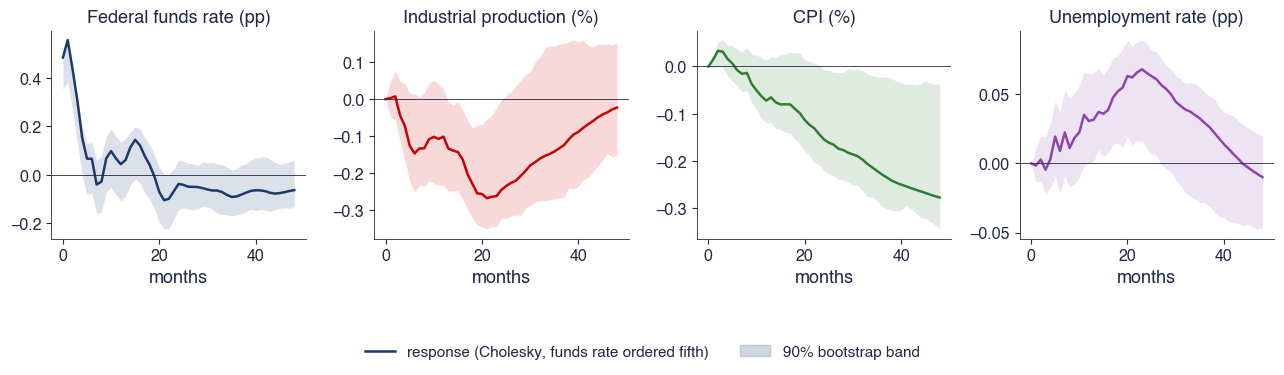

{'T': 354, 'sd': 0.4845888681384402, 'ip_min': -0.2686853247816295, 'ip_argmin': 21, 'ip_lo': -0.35287898125038253, 'ip_hi': -0.05403246414085656, 'u_max': 0.06808155804348627, 'p_max': 0.03325990637901027, 'p_argmax': 2, 'p_lo_at_max': 0.0029897595541024573, 'p48': -0.27694861193630504, 'p48_lo': -0.34396548217704337, 'p48_hi': -0.0365460866300002, 'fevd_ip24': 0.06563918601318663, 'fevd_ip48': 0.0503878360212232, 'fevd_ffr0': 0.9371302367478872, 'fevd_ffr24': 0.16064964720953423, 'root': 0.999874153802713, 'B': 200}


In [6]:
def ramey_monthly():
    """Monthly US data of Ramey (2016), sheet 'Monthly' of Monetarydat.xlsx: log IP, unemployment, log CPI, log
    commodity prices, funds rate, log nonborrowed and total reserves, log M1, 1-year Treasury yield, excess bond
    premium, Gertler-Karadi FF4 surprises (ff4_tc), Romer-Romer shocks; 1959:1 onward."""
    d = pd.read_excel(io.BytesIO(zip_member(RAMEY_MON, 'Monetarydat.xlsx')), sheet_name='Monthly')
    d.columns = [c.lower() for c in d.columns]
    d.index = pd.date_range('1959-01-01', periods=len(d), freq='MS')
    return d


def cee_model():
    d = ramey_monthly()[CEE['vars']].loc[CEE['start']:CEE['end']].copy()
    for c in ('lip', 'lcpi', 'lpcom', 'lnbr', 'ltr', 'lm1'):
        d[c] = 100 * d[c]
    return d, var_ols(d.values, CEE['p'])


def fig_cee(save_it=True, B=NBOOT):
    """CEE monetary VAR: responses to a one-standard-deviation funds-rate shock, 90% residual-bootstrap bands."""
    d, m = cee_model()
    H, k = CEE['H'], CEE['vars'].index(CEE['shock'])
    Th = irf(m['A'], np.linalg.cholesky(m['Sigma']), H)
    th = Th[:, :, k]
    draws, _ = bootstrap_var(m, chol, H, B=B)
    lo, hi = bands(draws[:, :, :, k])
    fe = fevd(Th)
    names = {'ffr': 'Federal funds rate (pp)', 'lip': 'Industrial production (%)', 'lcpi': 'CPI (%)',
             'unemp': 'Unemployment rate (pp)'}
    fig, axs = plt.subplots(1, 4, figsize=(13, 3.4))
    hh = np.arange(H + 1)
    for ax, v, c in zip(axs, ['ffr', 'lip', 'lcpi', 'unemp'], [st.MainBlue, st.IDAred, st.Forest, st.Purple]):
        i = CEE['vars'].index(v)
        band_plot(ax, hh, th[:, i], lo[:, i], hi[:, i], c, 'point estimate')
        ax.set_title(names[v])
        ax.set_xlabel('months')
    st.fig_legend_bottom(fig, [axs[0].lines[0], patch(st.MainBlue)],
                         ['response (Cholesky, funds rate ordered fifth)', '90% bootstrap band'], ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch3_cee_irf', save_it)
    i_ip, i_p, i_u = CEE['vars'].index('lip'), CEE['vars'].index('lcpi'), CEE['vars'].index('unemp')
    a = int(th[:, i_ip].argmin())
    return dict(T=int(len(m['U'])), sd=float(th[0, k]), ip_min=float(th[a, i_ip]), ip_argmin=a,
                ip_lo=float(lo[a, i_ip]), ip_hi=float(hi[a, i_ip]), u_max=float(th[:, i_u].max()),
                p_max=float(th[:24, i_p].max()), p_argmax=int(th[:24, i_p].argmax()), p_lo_at_max=float(lo[int(th[:24, i_p].argmax()), i_p]),
                p48=float(th[48, i_p]), p48_lo=float(lo[48, i_p]), p48_hi=float(hi[48, i_p]),
                fevd_ip24=float(fe[24, i_ip, k]), fevd_ip48=float(fe[48, i_ip, k]), fevd_ffr0=float(fe[0, k, k]),
                fevd_ffr24=float(fe[24, k, k]), root=max_root(m['A']), B=B)


print(fig_cee(save_it=False, B=200))

## 2. Oil supply and demand shocks (Kilian 2009)

- Responses, historical decomposition and the bias correction.

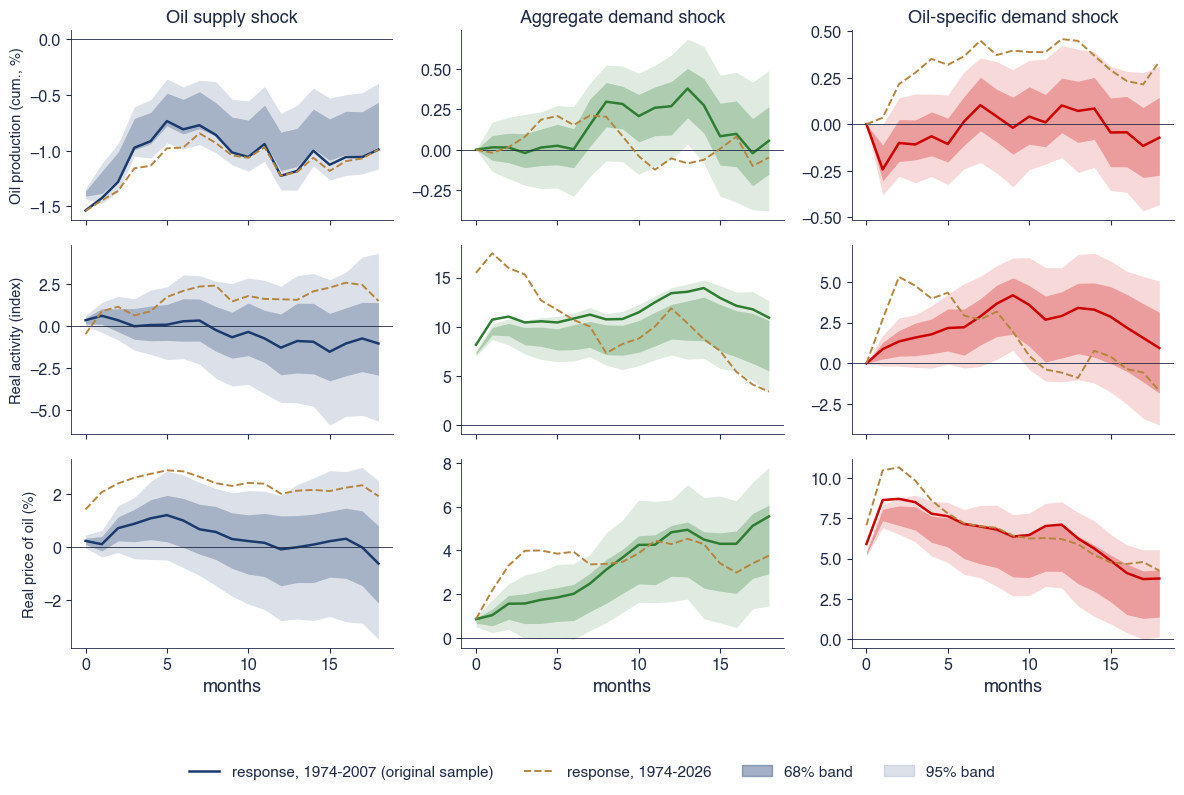

{'T': 384, 'first': '1976-01-01', 'last': '2007-12-01', 'T2': 604, 'last2': '2026-05-01', 'sup_p0': 0.23776300560955418, 'sup_p12': -0.08243301346306156, 'sup_p12_lo': -2.7818859347536087, 'sup_p12_hi': 1.9563802512678368, 'ad_p0': 0.8598255176759017, 'ad_p12': 4.827545176078828, 'ad_p12_lo': 1.6564656536873514, 'ad_p12_hi': 6.312031298867898, 'os_p0': 5.902882254856358, 'os_p12': 7.105162118868772, 'os_p12_lo': 3.1675867274377847, 'sup_q0': -1.536102302285947, 'ad_p12_2': 4.290197971761138, 'os_p12_2': 6.206674563127137, 'sup_p12_2': 2.025003127673212, 'fevd_p60': [0.006808761470555969, 0.6401919691596112, 0.35299926936983284], 'root': 0.9942785619337289, 'B': 200}


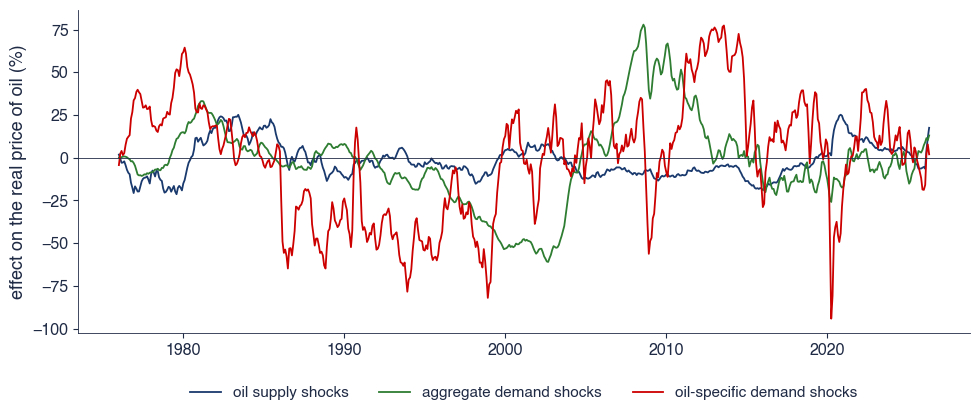

{'c2003_2008': {'sup': -11.772853103756576, 'ad': 125.8349778930569, 'os': 11.150284031445057}, 'c2008_2009': {'sup': 0.6841468061972638, 'ad': -35.16647823392347, 'os': -81.88334657032637}, 'c2020': {'sup': 0.2494119383179867, 'ad': -13.367084130143443, 'os': -102.55775564442408}, 'c2022': {'sup': -2.2089388602096385, 'ad': -0.6062825202015505, 'os': 42.912845374774534}, 'sd_sup': 10.073069569005378, 'sd_ad': 25.269952716040205, 'sd_os': 34.61261182096203}


{'root': 0.9942785619337289, 'root_c': 0.999891306832223, 'bias_mean': 0.008556880349458926, 'bias_own1': [-0.007620689827992827, -0.022226066321742177, -0.012254260882285761], 'p12': [-0.08243301346306156, 4.827545176078828, 7.105162118868772], 'p12c': [-0.03058200845771578, 4.946242838004161, 7.337277422906508], 'p12c_lo': [-2.296295832587726, 1.7399682112718866, 3.4831024417302507], 'p12c_hi': [3.0941042883557097, 6.681609194945617, 9.194926950042529]}


In [7]:
def oil_data():
    """Kilian (2009) variables, monthly: percent change of world crude oil production (EIA), the index of global real
    economic activity (FRED IGREA, Kilian 2009/2019) and the log real price of oil (refiner acquisition cost of
    imported crude, EIA Monthly Energy Review, deflated by US CPI)."""
    raw = zip_member(EIA_INTL, 'INTL.txt').decode('utf-8', 'ignore')
    prod = None
    for line in raw.splitlines():
        if EIA_PROD in line[:200]:
            js = json.loads(line)
            if js.get('series_id') == EIA_PROD:
                prod = pd.Series({pd.Timestamp(d[:4] + '-' + d[4:6] + '-01'): float(v) for d, v in js['data']
                                  if v not in (None, '--')}).sort_index()
                break
    mer = pd.read_csv(io.BytesIO(get_bytes(EIA_MER9)))
    r = mer[(mer['MSN'] == 'RAIMUUS') & (mer['YYYYMM'] % 100 != 13)]
    rac = pd.Series(pd.to_numeric(r['Value'], errors='coerce').values,
                    index=[pd.Timestamp(f'{y // 100}-{y % 100:02d}-01') for y in r['YYYYMM']]).dropna().sort_index()
    cpi = read_fred('CPIAUCSL')
    rea = read_fred('IGREA')
    d = pd.concat([100 * np.log(prod).diff(), rea, 100 * np.log(rac / cpi)], axis=1, keys=['dprod', 'rea', 'rpo']).dropna()
    d['rpo'] = d['rpo'] - d['rpo'].mean()
    return d


def kilian_ident(A, Sg, U):
    return np.linalg.cholesky(Sg) @ KIL_SIGN


def kilian_model(end=KIL['end']):
    d = oil_data().loc[KIL['start']:end]
    return d, var_ols(d.values, KIL['p'])


def fig_kilian(save_it=True, B=NBOOT):
    """Kilian (2009) Figure 3: responses to one-standard-deviation structural shocks (production cumulated), 68% and
    95% recursive-design wild bootstrap bands; original sample and extended sample."""
    d, m = kilian_model()
    H = KIL['H']
    th = irf(m['A'], kilian_ident(m['A'], m['Sigma'], m['U']), H)
    th[:, 0, :] = np.cumsum(th[:, 0, :], axis=0)
    draws, _ = bootstrap_var(m, kilian_ident, H, B=B, kind='wild')
    draws[:, :, 0, :] = np.cumsum(draws[:, :, 0, :], axis=1)
    lo, hi = bands(draws, (0.025, 0.975))
    lo2, hi2 = bands(draws, (0.16, 0.84))
    d2, m2 = kilian_model(end='2026-05-01')
    th2 = irf(m2['A'], kilian_ident(m2['A'], m2['Sigma'], m2['U']), H)
    th2[:, 0, :] = np.cumsum(th2[:, 0, :], axis=0)
    shocks = ['Oil supply shock', 'Aggregate demand shock', 'Oil-specific demand shock']
    resp = ['Oil production (cum., %)', 'Real activity (index)', 'Real price of oil (%)']
    fig, axs = plt.subplots(3, 3, figsize=(12, 7.6), sharex=True)
    hh = np.arange(H + 1)
    cols = [st.MainBlue, st.Forest, st.IDAred]
    for j in range(3):
        for i in range(3):
            ax = axs[i, j]
            band_plot(ax, hh, th[:, i, j], lo[:, i, j], hi[:, i, j], cols[j], 'response, 1974-2007', lo2[:, i, j], hi2[:, i, j])
            ax.plot(hh, th2[:, i, j], color=st.Amber, lw=1.4, ls='--', label='response, 1974-2026')
            if i == 0:
                ax.set_title(shocks[j])
            if j == 0:
                ax.set_ylabel(resp[i], fontsize=10.5)
            if i == 2:
                ax.set_xlabel('months')
    st.fig_legend_bottom(fig, [axs[0, 0].lines[0], axs[0, 0].lines[2], patch(st.MainBlue, 0.4), patch(st.MainBlue, 0.15)],
                         ['response, 1974-2007 (original sample)', 'response, 1974-2026', '68% band', '95% band'], ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.05, 1, 1))
    save('ats_ch3_kilian_irf', save_it)
    fe = fevd(irf(m['A'], kilian_ident(m['A'], m['Sigma'], m['U']), 60))
    return dict(T=int(len(m['U'])), first=str(d.index[KIL['p']].date()), last=str(d.index[-1].date()),
                T2=int(len(m2['U'])), last2=str(d2.index[-1].date()),
                sup_p0=float(th[0, 2, 0]), sup_p12=float(th[12, 2, 0]), sup_p12_lo=float(lo[12, 2, 0]), sup_p12_hi=float(hi[12, 2, 0]),
                ad_p0=float(th[0, 2, 1]), ad_p12=float(th[12, 2, 1]), ad_p12_lo=float(lo[12, 2, 1]), ad_p12_hi=float(hi[12, 2, 1]),
                os_p0=float(th[0, 2, 2]), os_p12=float(th[12, 2, 2]), os_p12_lo=float(lo[12, 2, 2]), sup_q0=float(th[0, 0, 0]),
                ad_p12_2=float(th2[12, 2, 1]), os_p12_2=float(th2[12, 2, 2]), sup_p12_2=float(th2[12, 2, 0]),
                fevd_p60=[float(x) for x in fe[60, 2]], root=max_root(m['A']), B=B)


def fig_kilian_hd(save_it=True):
    """Historical decomposition of the real price of oil (Kilian 2009, Figure 4) on the extended sample."""
    d, m = kilian_model(end='2026-05-01')
    B0 = kilian_ident(m['A'], m['Sigma'], m['U'])
    E = np.linalg.solve(B0, m['U'].T).T                         # structural shocks
    T = len(E)
    Theta = irf(m['A'], B0, T)
    contrib = np.zeros((T, 3))
    for t in range(T):
        contrib[t] = (Theta[:t + 1, 2, :][::-1] * E[:t + 1]).sum(axis=0)
    idx = d.index[KIL['p']:]
    fig, ax = plt.subplots(figsize=(11.5, 4.2))
    labs = ['oil supply shocks', 'aggregate demand shocks', 'oil-specific demand shocks']
    for j, c in enumerate([st.MainBlue, st.Forest, st.IDAred]):
        ax.plot(idx, contrib[:, j], color=c, lw=1.3, label=labs[j])
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylabel('effect on the real price of oil (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    save('ats_ch3_kilian_hd', save_it)
    s = pd.DataFrame(contrib, index=idx, columns=['sup', 'ad', 'os'])

    def chg(a, b):
        return {k: float(s.loc[b, k] - s.loc[a, k]) for k in s.columns}
    return dict(c2003_2008=chg('2003-01-01', '2008-06-01'), c2008_2009=chg('2008-06-01', '2009-02-01'),
                c2020=chg('2020-01-01', '2020-04-01'), c2022=chg('2021-06-01', '2022-06-01'),
                sd_sup=float(s['sup'].std()), sd_ad=float(s['ad'].std()), sd_os=float(s['os'].std()))


def kilian_bias_demo(B=NBOOT):
    """Kilian (1998) bias correction on the oil VAR (stationary, root < 1): bias of the slope coefficients and the
    change in the 12-month response of the real oil price to each shock; corrected bootstrap bands."""
    d, m = kilian_model()
    bias = kilian_bias(m, B=200)
    Ac = shrink_bias(m['A'], bias)
    B0 = kilian_ident(m['A'], m['Sigma'], m['U'])
    th, thc = irf(m['A'], B0, KIL['H']), irf(Ac, B0, KIL['H'])
    dr, _ = bootstrap_var(m, kilian_ident, KIL['H'], B=B, kind='wild', bias=bias)
    lo, hi = bands(dr, (0.025, 0.975))
    return dict(root=max_root(m['A']), root_c=max_root(Ac), bias_mean=float(np.abs(bias).mean()),
                bias_own1=[float(x) for x in np.diag(bias[0])],
                p12=[float(x) for x in th[12, 2]], p12c=[float(x) for x in thc[12, 2]],
                p12c_lo=[float(x) for x in lo[12, 2]], p12c_hi=[float(x) for x in hi[12, 2]])


print(fig_kilian(save_it=False, B=200))
print(fig_kilian_hd(save_it=False))
print(kilian_bias_demo(B=100))

## 3. Long-run restrictions (Blanchard and Quah 1989)

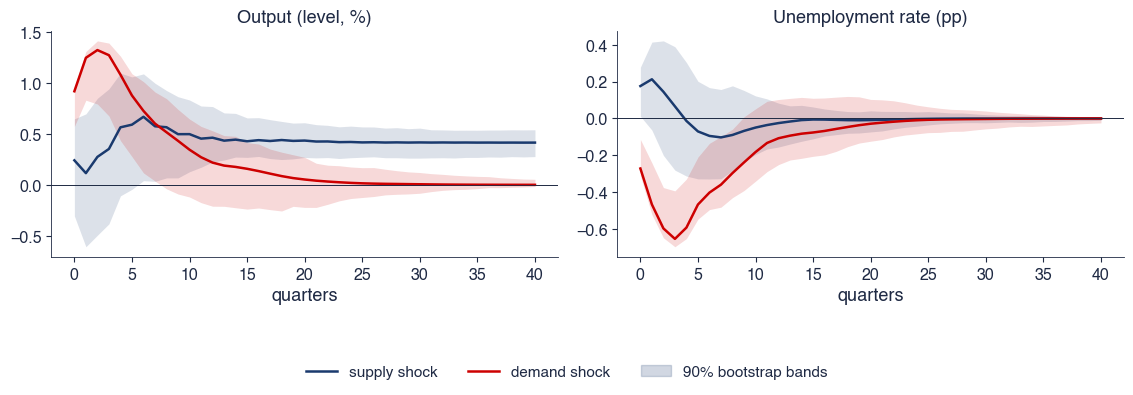

{'T': 151, 'first': '1950-04-01', 'last': '1987-10-01', 'dem_y_peak': 1.3263333274703382, 'dem_y_argpeak': 2, 'dem_y_peak_lo': 0.7950961785106945, 'dem_y40': 0.0003011356527979498, 'dem_u_min': -0.6539114980344546, 'dem_u_argmin': 3, 'sup_y40': 0.41574775420875654, 'sup_y40_lo': 0.2780621712212298, 'sup_y40_hi': 0.5417453211978711, 'sup_u0': 0.1757977225556358, 'sup_u_max': 0.21267280335405517, 'fevd_y4_dem': 0.9217153341373552, 'fevd_y40_dem': 0.5428562880247214, 'fevd_u4_dem': 0.9335072824237727, 'B': 200}


In [8]:
def bq_data():
    """Blanchard and Quah (1989): quarterly real GNP growth (FRED GNPC96) and the unemployment rate of men aged 20 and
    over (FRED LNS14000025, quarterly average)."""
    gnp = read_fred('GNPC96')
    u = read_fred('LNS14000025').resample('QS').mean()
    return pd.concat([100 * np.log(gnp).diff(), u], axis=1, keys=['dy', 'u']).dropna()


def bq_impact(A, Sigma):
    """Blanchard-Quah: B0 with a lower-triangular long-run matrix Theta(1) = (I - A(1))^{-1} B0."""
    n = Sigma.shape[0]
    C1 = np.linalg.inv(np.eye(n) - A.sum(axis=0))
    L = np.linalg.cholesky(C1 @ Sigma @ C1.T)
    return np.linalg.solve(C1, L)


def bq_model():
    d = bq_data().loc[BQ['start']:BQ['end']].copy()
    pre = d.index < BQ['brk']
    d.loc[pre, 'dy'] -= d.loc[pre, 'dy'].mean()
    d.loc[~pre, 'dy'] -= d.loc[~pre, 'dy'].mean()
    t = np.arange(len(d))
    d['u'] = d['u'] - np.polyval(np.polyfit(t, d['u'], 1), t)
    return d, var_ols(d.values, BQ['p'])


def bq_ident(A, S, U):
    """Long-run identification; signs: the supply shock raises output in the long run, the demand shock raises output
    on impact."""
    B0 = bq_impact(A, S)
    C1 = np.linalg.inv(np.eye(2) - A.sum(axis=0)) @ B0
    return B0 @ np.diag([np.sign(C1[0, 0]), np.sign(B0[0, 1])])


def fig_bq(save_it=True, B=NBOOT):
    """Blanchard-Quah responses of the output level and of unemployment to supply and demand shocks."""
    d, m = bq_model()
    H = BQ['H']
    th = irf(m['A'], bq_ident(m['A'], m['Sigma'], m['U']), H)
    th[:, 0, :] = np.cumsum(th[:, 0, :], axis=0)
    draws, _ = bootstrap_var(m, bq_ident, H, B=B)
    draws[:, :, 0, :] = np.cumsum(draws[:, :, 0, :], axis=1)
    lo, hi = bands(draws, (0.05, 0.95))
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 3.6))
    hh = np.arange(H + 1)
    for ax, i, title in [(axs[0], 0, 'Output (level, %)'), (axs[1], 1, 'Unemployment rate (pp)')]:
        band_plot(ax, hh, th[:, i, 0], lo[:, i, 0], hi[:, i, 0], st.MainBlue, 'supply shock')
        band_plot(ax, hh, th[:, i, 1], lo[:, i, 1], hi[:, i, 1], st.IDAred, 'demand shock')
        ax.set_title(title)
        ax.set_xlabel('quarters')
    st.fig_legend_bottom(fig, [axs[0].lines[0], axs[0].lines[2], patch(st.MainBlue)],
                         ['supply shock', 'demand shock', '90% bootstrap bands'], ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch3_bq', save_it)
    Thc = irf(m['A'], bq_ident(m['A'], m['Sigma'], m['U']), 40)
    Thc[:, 0, :] = np.cumsum(Thc[:, 0, :], axis=0)                # variance decomposition of the output level
    fe = fevd(Thc)
    a = int(th[:, 0, 1].argmax())
    return dict(T=int(len(m['U'])), first=str(d.index[BQ['p']].date()), last=str(d.index[-1].date()),
                dem_y_peak=float(th[a, 0, 1]), dem_y_argpeak=a, dem_y_peak_lo=float(lo[a, 0, 1]), dem_y40=float(th[40, 0, 1]),
                dem_u_min=float(th[:, 1, 1].min()), dem_u_argmin=int(th[:, 1, 1].argmin()),
                sup_y40=float(th[40, 0, 0]), sup_y40_lo=float(lo[40, 0, 0]), sup_y40_hi=float(hi[40, 0, 0]),
                sup_u0=float(th[0, 1, 0]), sup_u_max=float(th[:, 1, 0].max()),
                fevd_y4_dem=float(fe[4, 0, 1]), fevd_y40_dem=float(fe[40, 0, 1]), fevd_u4_dem=float(fe[4, 1, 1]), B=B)


print(fig_bq(save_it=False, B=200))

## 4. Sign restrictions: the rotation set and Uhlig (2005)

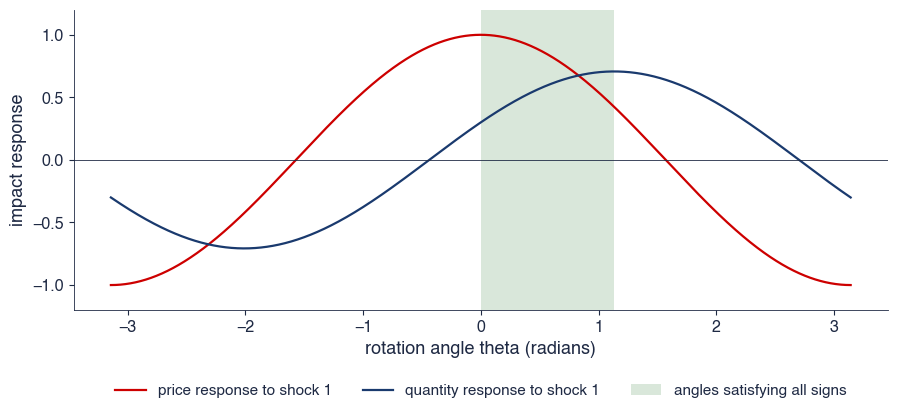

{'th_lo': 0.003141592653590042, 'th_hi': 1.1309733552923253, 'share': 0.17991004497751126, 'p_lo': 0.4257792915650728, 'p_hi': 0.9999950652018582, 'q_lo': 0.3020101170580427, 'q_hi': 0.7071057905025312, 's11': np.float64(1.0), 's12': np.float64(0.3), 's22': np.float64(0.5)}


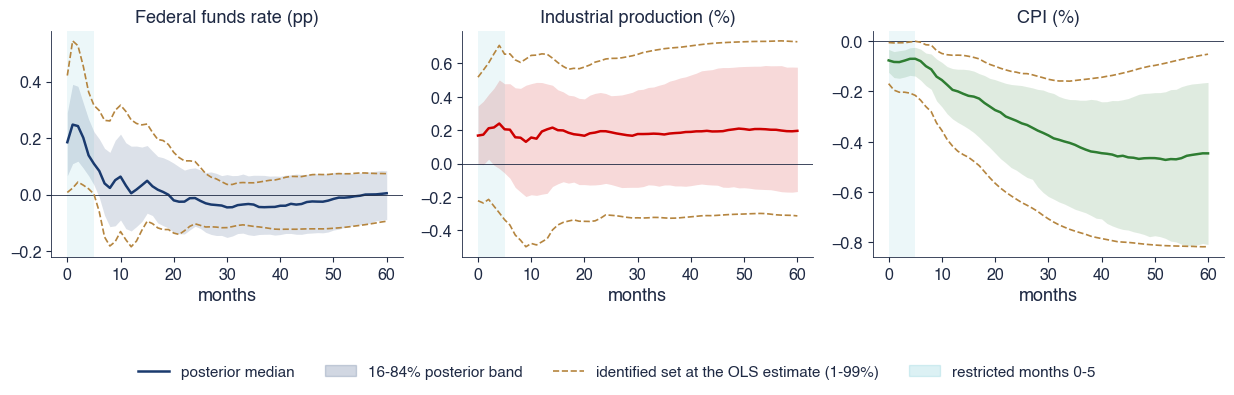

{'n_keep': 296, 'ndraw': 300, 'tried': 9170, 'acc_rate': 0.04115, 'ip12': 0.1919236847121593, 'ip12_lo': -0.18334438531495215, 'ip12_hi': 0.48492430523710456, 'ip_share_neg12': 0.3108108108108108, 'set12_lo': -0.4683227476265623, 'set12_hi': 0.6563277923965436, 'set_ip0_lo': -0.2708657002763361, 'set_ip0_hi': 0.5528442512576501, 'p24': -0.3171437129021315, 'ffr0': 0.18527884586351004, 'T': 456}


In [9]:
def haar(n, rng):
    """A random orthogonal matrix from the Haar measure: QR of a Gaussian matrix with sign normalisation
    (Rubio-Ramirez, Waggoner and Zha 2010)."""
    Q, R = np.linalg.qr(rng.standard_normal((n, n)))
    return Q @ np.diag(np.sign(np.diag(R)))


def niw_draw(m, rng):
    """One draw of (A, Sigma) from the Normal-inverse-Wishart posterior under a flat prior."""
    X, U, p = m['X'], m['U'], m['p']
    n = U.shape[1]
    T, k = X.shape
    S = U.T @ U
    Sig = stats.invwishart.rvs(df=T - k, scale=S, random_state=rng)
    XtXi = np.linalg.inv(X.T @ X)
    Bd = m['B'] + np.linalg.cholesky(XtXi) @ rng.standard_normal((k, n)) @ np.linalg.cholesky(Sig).T
    A = np.stack([Bd[j * n:(j + 1) * n].T for j in range(p)])
    return A, Sig


def fig_rotation(save_it=True):
    """Two-variable demand and supply example: impact responses B0(theta) = P R(theta) of price and quantity to the
    first shock; the sign restrictions (price up, quantity up for a demand shock; price up, quantity down for a supply
    shock) hold on a set of angles, not at a point."""
    S = np.array([[1.0, 0.3], [0.3, 0.5]])                     # covariance of (price, quantity) innovations
    P = np.linalg.cholesky(S)
    th = np.linspace(-np.pi, np.pi, 2001)
    b = np.array([P @ np.array([np.cos(t), np.sin(t)]) for t in th])     # first column of P R(theta)
    c = np.array([P @ np.array([-np.sin(t), np.cos(t)]) for t in th])    # second column
    ok = (b[:, 0] > 0) & (b[:, 1] > 0) & (c[:, 0] * c[:, 1] < 0)   # demand: (+, +); supply: (+, -) up to its sign
    fig, ax = plt.subplots(figsize=(10.5, 3.9))
    ax.plot(th, b[:, 0], color=st.IDAred, lw=1.6, label='price response to shock 1')
    ax.plot(th, b[:, 1], color=st.MainBlue, lw=1.6, label='quantity response to shock 1')
    ax.fill_between(th, -1.2, 1.2, where=ok, color=st.Forest, alpha=0.18, lw=0, label='angles satisfying all signs')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlabel('rotation angle theta (radians)')
    ax.set_ylabel('impact response')
    ax.set_ylim(-1.2, 1.2)
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch3_rotation', save_it)
    sel = th[ok]
    return dict(th_lo=float(sel.min()), th_hi=float(sel.max()), share=float(ok.mean()),
                p_lo=float(b[ok, 0].min()), p_hi=float(b[ok, 0].max()), q_lo=float(b[ok, 1].min()), q_hi=float(b[ok, 1].max()),
                s11=S[0, 0], s12=S[0, 1], s22=S[1, 1])


def uhlig_data():
    d = ramey_monthly()[UHL['vars']].loc[UHL['start']:UHL['end']].copy()
    for c in ('lip', 'lcpi', 'lpcom', 'lnbr', 'ltr'):
        d[c] = 100 * d[c]
    return d


def uhlig_check(Theta_q):
    """Uhlig (2005) restrictions for months 0..K: CPI <= 0, commodity prices <= 0, nonborrowed reserves <= 0,
    funds rate >= 0 (Theta_q: H+1 x n responses to the candidate shock)."""
    K = UHL['K']
    v = UHL['vars']
    R = Theta_q[:K + 1]
    return (np.all(R[:, v.index('lcpi')] <= 0) and np.all(R[:, v.index('lpcom')] <= 0)
            and np.all(R[:, v.index('lnbr')] <= 0) and np.all(R[:, v.index('ffr')] >= 0))


def uhlig_draws(m, ndraw=1000, nrot=200, seed=SEED, H=UHL['H']):
    """Posterior draws (flat NIW) times Haar rotations: keep the impulse vectors that satisfy the restrictions."""
    rng = np.random.default_rng(seed)
    n = m['A'].shape[1]
    keep, tried = [], 0
    for _ in range(ndraw):
        A, Sg = niw_draw(m, rng)
        if max_root(A) > 1.01:
            continue
        Phi = ma_coefs(A, H)
        P = np.linalg.cholesky(Sg)
        for _ in range(nrot):
            tried += 1
            q = rng.standard_normal(n)
            q /= np.linalg.norm(q)
            th = Phi @ (P @ q)
            if uhlig_check(th):
                keep.append(th)
                break
            if uhlig_check(-th):
                keep.append(-th)
                break
    return np.array(keep), tried


def uhlig_set(m, nrot=20000, seed=SEED, H=UHL['H']):
    """The identified set at the OLS estimate: all accepted rotations for fixed (A, Sigma)."""
    rng = np.random.default_rng(seed)
    n = m['A'].shape[1]
    Phi = ma_coefs(m['A'], H)
    P = np.linalg.cholesky(m['Sigma'])
    Q = rng.standard_normal((nrot, n))
    Q /= np.linalg.norm(Q, axis=1, keepdims=True)
    acc = []
    for q in Q:
        th = Phi @ (P @ q)
        if uhlig_check(th):
            acc.append(th)
        elif uhlig_check(-th):
            acc.append(-th)
    return np.array(acc)


def fig_uhlig(save_it=True, ndraw=1000):
    """Uhlig (2005) Figure 6 analogue: responses to a contractionary monetary shock of one standard deviation;
    median and 16-84% posterior bands, and the identified set at the OLS estimate."""
    d = uhlig_data()
    m = var_ols(d.values, UHL['p'], const=False)
    keep, tried = uhlig_draws(m, ndraw=ndraw)
    iset = uhlig_set(m)
    v = UHL['vars']
    f = v.index('ffr')
    H = UHL['H']
    kn, sn = keep, iset                                         # one-standard-deviation shocks (unit impulse vector)
    med = np.median(kn, axis=0)
    lo, hi = np.quantile(kn, 0.16, axis=0), np.quantile(kn, 0.84, axis=0)
    slo, shi = np.quantile(sn, 0.01, axis=0), np.quantile(sn, 0.99, axis=0)
    fig, axs = plt.subplots(1, 3, figsize=(12.5, 3.6))
    hh = np.arange(H + 1)
    for ax, name, title, c in [(axs[0], 'ffr', 'Federal funds rate (pp)', st.MainBlue),
                               (axs[1], 'lip', 'Industrial production (%)', st.IDAred),
                               (axs[2], 'lcpi', 'CPI (%)', st.Forest)]:
        i = v.index(name)
        band_plot(ax, hh, med[:, i], lo[:, i], hi[:, i], c, 'posterior median')
        ax.plot(hh, slo[:, i], color=st.Amber, ls='--', lw=1.2, label='identified set at the OLS estimate')
        ax.plot(hh, shi[:, i], color=st.Amber, ls='--', lw=1.2, label='_s')
        ax.axvspan(0, UHL['K'], color=st.Teal, alpha=0.08, lw=0)
        ax.set_title(title)
        ax.set_xlabel('months')
    st.fig_legend_bottom(fig, [axs[0].lines[0], patch(st.MainBlue), axs[0].lines[2], patch(st.Teal, 0.15)],
                         ['posterior median', '16-84% posterior band', 'identified set at the OLS estimate (1-99%)',
                          'restricted months 0-5'], ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch3_uhlig', save_it)
    i = v.index('lip')
    return dict(n_keep=int(len(keep)), ndraw=ndraw, tried=int(tried), acc_rate=float(len(iset) / 20000),
                ip12=float(med[12, i]), ip12_lo=float(lo[12, i]), ip12_hi=float(hi[12, i]),
                ip_share_neg12=float((kn[:, 12, i] < 0).mean()), set12_lo=float(slo[12, i]), set12_hi=float(shi[12, i]),
                set_ip0_lo=float(sn[:, 0, i].min()), set_ip0_hi=float(sn[:, 0, i].max()),
                p24=float(med[24, v.index('lcpi')]), ffr0=float(med[0, f]), T=int(len(m['U'])))


print(fig_rotation(save_it=False))
print(fig_uhlig(save_it=False, ndraw=300))

## 5. External instruments (Gertler and Karadi 2015)

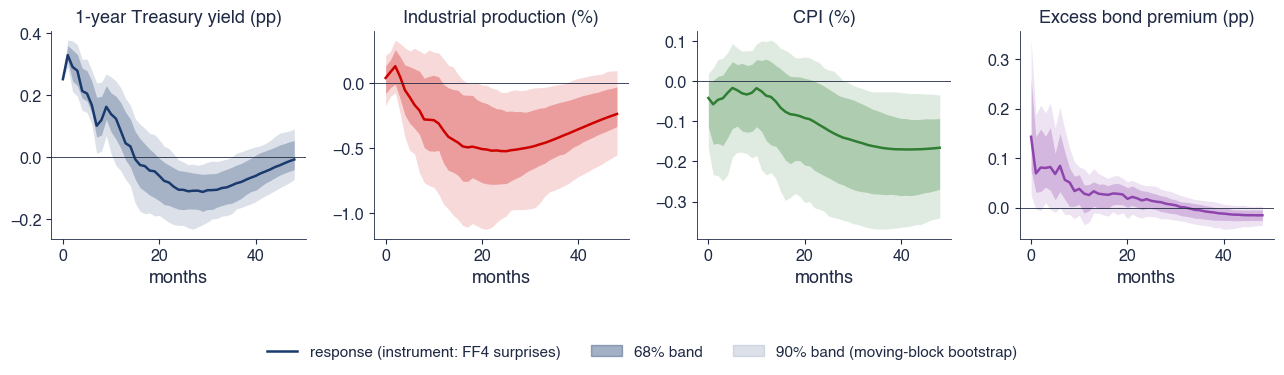

{'T': 384, 'Tz': 258, 'F': np.float64(17.72192237168085), 'F_hom': np.float64(21.879951295617563), 'r2': np.float64(0.07845652293744299), 'b': np.float64(1.1585420617746924), 'ebp0': 0.14316784324644366, 'ebp0_lo': 0.025458768445483625, 'ebp0_hi': 0.33859958161161763, 'ip_min': -0.5215266379299511, 'ip_argmin': 25, 'ip_min_lo': -1.0208904168352042, 'ip_min_hi': -0.06901862354555181, 'cpi24': -0.1160471472894767, 'cpi24_lo': -0.32417821485431614, 'cpi24_hi': 0.032727649680226366, 'gs1_12': 0.08358490786916734, 'B': 200}


In [10]:
def first_stage(U, z):
    """Regression of the policy residual u1 on the instrument z: coefficient, robust t and F = t^2."""
    z = z - z.mean()
    u = U[:, 0] - U[:, 0].mean()
    b = (z @ u) / (z @ z)
    e = u - b * z
    se = np.sqrt(np.sum(z ** 2 * e ** 2)) / (z @ z)
    return dict(b=b, t=b / se, F=(b / se) ** 2, F_hom=(b / (np.sqrt(e @ e / (len(z) - 1) / (z @ z)))) ** 2,
                r2=1 - (e @ e) / (u @ u))


def proxy_impact(U, z, scale=1.0):
    """External-instrument identification (Stock and Watson 2012; Mertens and Ravn 2013): the impact column is
    proportional to Cov(u, z); normalised so that the first variable moves by `scale` on impact."""
    c = (U - U.mean(axis=0)).T @ (z - z.mean())
    return scale * c / c[0]


def proxy_irf(m, z_full, H, scale=1.0):
    """Impulse responses to the instrumented shock; z_full aligned with the VAR sample (NaN outside its span)."""
    z = np.asarray(z_full, float)[m['p']:]
    ok = ~np.isnan(z)
    b = proxy_impact(m['U'][ok], z[ok], scale)
    return ma_coefs(m['A'], H) @ b, first_stage(m['U'][ok], z[ok])


def proxy_mbb(m, z_full, H, B=NBOOT, scale=1.0, seed=SEED, block=None):
    """Moving-block bootstrap of residuals and instrument jointly (Jentsch and Lunsford 2019)."""
    rng = np.random.default_rng(seed)
    A, U, p, Y = m['A'], m['U'], m['p'], m['Y']
    z = np.asarray(z_full, float)[p:]
    T = len(U)
    ell = block or int(round(5.03 * T ** 0.25))
    Xdet = m['X'][:, A.shape[1] * p:]
    starts = np.arange(T - ell + 1)
    centre = np.array([U[(t % ell) + starts].mean(axis=0) for t in range(T)])
    out = []
    for b in range(B):
        idx = np.concatenate([np.arange(s, s + ell) for s in rng.choice(starts, int(np.ceil(T / ell)))])[:T]
        Ub = U[idx] - centre
        zb = z[idx]
        Yb = simulate_var(A, m['det'], Xdet, Ub, Y[:p])
        mb = var_ols(Yb, p, const=m['const'])
        ok = ~np.isnan(zb)
        try:
            bb = proxy_impact(mb['U'][ok], zb[ok], scale)
            out.append(ma_coefs(mb['A'], H) @ bb)
        except Exception:
            continue
    return np.array(out)


def gk_model():
    r = ramey_monthly()
    d = r[GK['vars']].loc[GK['start']:GK['end']].copy()
    for c in ('lip', 'lcpi'):
        d[c] = 100 * d[c]
    z = r['ff4_tc'].loc[GK['start']:GK['end']].copy()
    z[z.index < GK['zstart']] = np.nan
    return d, z, var_ols(d.values, GK['p'])


def fig_gk(save_it=True, B=NBOOT):
    """Gertler-Karadi proxy SVAR: responses to a monetary policy shock that raises the 1-year yield by 25 bp on
    impact; 68% and 90% moving-block bootstrap bands; first-stage F."""
    d, z, m = gk_model()
    H = GK['H']
    th, fs = proxy_irf(m, z.values, H, scale=0.25)
    draws = proxy_mbb(m, z.values, H, B=B, scale=0.25)
    lo, hi = bands(draws, (0.05, 0.95))
    lo2, hi2 = bands(draws, (0.16, 0.84))
    titles = ['1-year Treasury yield (pp)', 'Industrial production (%)', 'CPI (%)', 'Excess bond premium (pp)']
    fig, axs = plt.subplots(1, 4, figsize=(13, 3.4))
    hh = np.arange(H + 1)
    for i, (ax, c) in enumerate(zip(axs, [st.MainBlue, st.IDAred, st.Forest, st.Purple])):
        band_plot(ax, hh, th[:, i], lo[:, i], hi[:, i], c, 'proxy SVAR', lo2[:, i], hi2[:, i])
        ax.set_title(titles[i])
        ax.set_xlabel('months')
    st.fig_legend_bottom(fig, [axs[0].lines[0], patch(st.MainBlue, 0.4), patch(st.MainBlue, 0.15)],
                         ['response (instrument: FF4 surprises)', '68% band', '90% band (moving-block bootstrap)'], ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch3_gk', save_it)
    a = int(th[:, 1].argmin())
    return dict(T=int(len(m['U'])), Tz=int(z.notna().sum()), F=fs['F'], F_hom=fs['F_hom'], r2=fs['r2'], b=fs['b'],
                ebp0=float(th[0, 3]), ebp0_lo=float(lo[0, 3]), ebp0_hi=float(hi[0, 3]),
                ip_min=float(th[a, 1]), ip_argmin=a, ip_min_lo=float(lo[a, 1]), ip_min_hi=float(hi[a, 1]),
                cpi24=float(th[24, 2]), cpi24_lo=float(lo[24, 2]), cpi24_hi=float(hi[24, 2]), gs1_12=float(th[12, 0]),
                B=int(len(draws)))


print(fig_gk(save_it=False, B=200))

## 6. Local projections against VARs

- LP-IV with the same instrument; the bias–variance simulation (200 replications here, 500 on the slides).

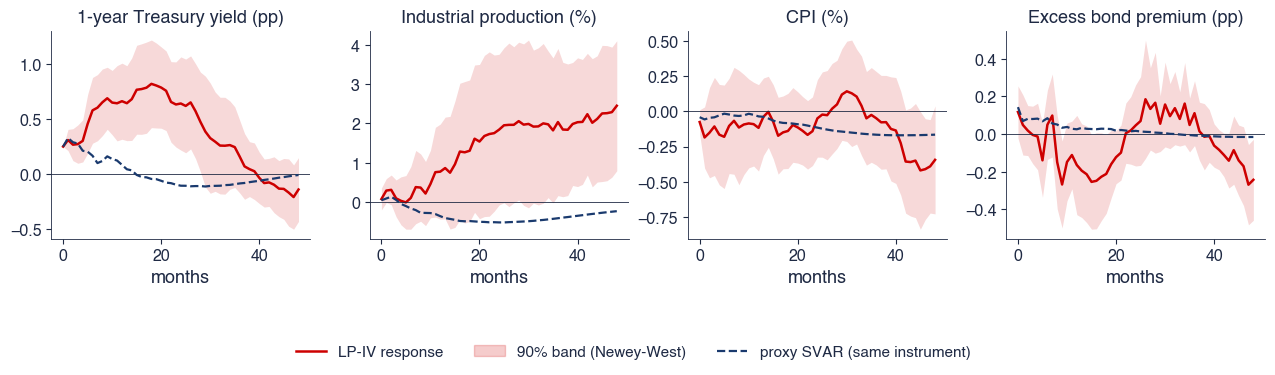

{'F0': 21.477753851146147, 'ip24': 1.8396155975445587, 'ip24_se': 1.1658709586361558, 'cpi24': -0.05058966723463835, 'cpi24_se': 0.16699948571088763, 'svar_ip24': -0.5206042629851759, 'svar_cpi24': -0.1160471472894767, 'ratio_se_ip24': 0.63375792213999, 'ebp0': 0.11749509986482992, 'ebp0_se': 0.08440901534167831, 'T': 270}


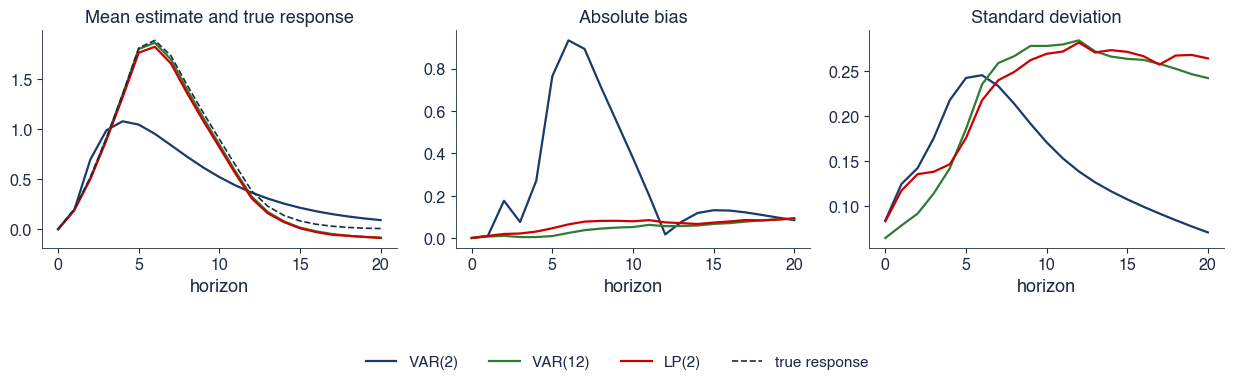

{'peak': 1.885, 'VAR(2)_bias_4': -0.27, 'VAR(2)_bias_8': -0.715, 'VAR(2)_bias_12': -0.017, 'VAR(2)_bias_16': 0.13, 'VAR(2)_sd_4': 0.218, 'VAR(2)_sd_8': 0.214, 'VAR(2)_sd_12': 0.139, 'VAR(2)_sd_16': 0.1, 'VAR(2)_rmse_4': 0.347, 'VAR(2)_rmse_8': 0.746, 'VAR(2)_rmse_12': 0.14, 'VAR(2)_rmse_16': 0.164, 'VAR(12)_bias_4': -0.005, 'VAR(12)_bias_8': -0.045, 'VAR(12)_bias_12': -0.056, 'VAR(12)_bias_16': -0.071, 'VAR(12)_sd_4': 0.142, 'VAR(12)_sd_8': 0.267, 'VAR(12)_sd_12': 0.285, 'VAR(12)_sd_16': 0.263, 'VAR(12)_rmse_4': 0.142, 'VAR(12)_rmse_8': 0.271, 'VAR(12)_rmse_12': 0.29, 'VAR(12)_rmse_16': 0.272, 'LP(2)_bias_4': -0.031, 'LP(2)_bias_8': -0.081, 'LP(2)_bias_12': -0.074, 'LP(2)_bias_16': -0.078, 'LP(2)_sd_4': 0.147, 'LP(2)_sd_8': 0.249, 'LP(2)_sd_12': 0.282, 'LP(2)_sd_16': 0.267, 'LP(2)_rmse_4': 0.15, 'LP(2)_rmse_8': 0.262, 'LP(2)_rmse_12': 0.292, 'LP(2)_rmse_16': 0.278, 'true8': 1.439}


In [11]:
def lp_iv_se(y, x, z, W, L):
    """Newey-West standard error (L lags) of the 2SLS coefficient of y on x instrumented by z, controls W."""
    D = np.column_stack([y, x, z, W])
    ok = ~np.isnan(D).any(axis=1)
    b, e, Pz = tsls(y[ok], x[ok], z[ok], W[ok])
    return float(np.sqrt(nw_se(Pz, e, L)[0, 0]))


def fig_lp_gk(save_it=True):
    """LP-IV with the same instrument (Ramey 2016, Figure 3B specification: 2 lags, 1990:1-2012:6) against the proxy
    SVAR: the 1-year yield is the endogenous regressor, FF4 its instrument."""
    r = ramey_monthly()
    d = r[['gs1', 'lip', 'lcpi', 'ebp', 'ff4_tc']].copy()
    d['lip'] *= 100
    d['lcpi'] *= 100
    H = LPGK['H']
    # origins t in 1990:1-2012:6; the leads y_{t+h} may reach beyond 2012:6
    full = d.loc[:'2015-12-01']
    Wf = lags_of(full, ['gs1', 'lip', 'lcpi', 'ebp', 'ff4_tc'], LPGK['p'])
    t0 = full.index.get_loc(pd.Timestamp(LPGK['start']))
    t1 = full.index.get_loc(pd.Timestamp(LPGK['end'])) + 1
    res = {}
    for v in ['gs1', 'lip', 'lcpi', 'ebp']:
        bs, ses, Fs = [], [], []
        for h in range(H + 1):
            y = full[v].shift(-h).values[t0:t1]
            x, z, W = full['gs1'].values[t0:t1], full['ff4_tc'].values[t0:t1], Wf[t0:t1]
            b, se, F = lp_iv(y, x, z, W, 0)
            bs.append(b[0])
            ses.append(lp_iv_se(y, x, z, W, h + 1))
            Fs.append(F[0])
        res[v] = (0.25 * np.array(bs), 0.25 * np.array(ses), np.array(Fs))
    _, zg, mg = gk_model()
    th, _ = proxy_irf(mg, zg.values, H, scale=0.25)
    titles = ['1-year Treasury yield (pp)', 'Industrial production (%)', 'CPI (%)', 'Excess bond premium (pp)']
    fig, axs = plt.subplots(1, 4, figsize=(13, 3.4))
    hh = np.arange(H + 1)
    for i, (ax, v) in enumerate(zip(axs, ['gs1', 'lip', 'lcpi', 'ebp'])):
        b, se, _ = res[v]
        band_plot(ax, hh, b, b - 1.645 * se, b + 1.645 * se, st.IDAred, 'LP-IV')
        ax.plot(hh, th[:, i], color=st.MainBlue, lw=1.6, ls='--', label='proxy SVAR')
        ax.set_title(titles[i])
        ax.set_xlabel('months')
    st.fig_legend_bottom(fig, [axs[0].lines[0], patch(st.IDAred), axs[0].lines[2]],
                         ['LP-IV response', '90% band (Newey-West)', 'proxy SVAR (same instrument)'], ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch3_lp_gk', save_it)
    ip, cpi = res['lip'], res['lcpi']
    return dict(F0=float(res['gs1'][2][0]), ip24=float(ip[0][24]), ip24_se=float(ip[1][24]), cpi24=float(cpi[0][24]),
                cpi24_se=float(cpi[1][24]), svar_ip24=float(th[24, 1]), svar_cpi24=float(th[24, 2]),
                ratio_se_ip24=float(ip[1][24] / max(1e-9, abs(ip[0][24]))),
                ebp0=float(res['ebp'][0][0]), ebp0_se=float(res['ebp'][1][0]), T=int(t1 - t0))


def sim_dgp(T, rng, burn=100):
    """x_t = 0.5 x_{t-1} + e_t; y_t = 0.6 y_{t-1} + sum_j PSI_j e_{t-j} + u_t: a finite-order VAR is misspecified."""
    n = T + burn
    e, u = rng.standard_normal(n), rng.standard_normal(n)
    x, y = np.zeros(n), np.zeros(n)
    L = len(PSI)
    for t in range(1, n):
        x[t] = 0.5 * x[t - 1] + e[t]
        y[t] = 0.6 * y[t - 1] + sum(PSI[j] * e[t - j] for j in range(min(L, t + 1))) + u[t]
    return np.column_stack([x, y])[burn:]


def true_irf(H):
    """Response of y to a unit shock e (x ordered first): y_h = 0.6 y_{h-1} + PSI_h."""
    r = np.zeros(H + 1)
    for h in range(H + 1):
        r[h] = (0.6 * r[h - 1] if h else 0) + (PSI[h] if h < len(PSI) else 0)
    return r


def lp_sim_estimates(Y, p, H):
    """Recursive LP: y_{t+h} on x_t, controls p lags of (x, y) (x_t is the shock up to scale, ordered first)."""
    x, y = Y[:, 0], Y[:, 1]
    W = np.column_stack([np.r_[np.full(j, np.nan), Y[:-j, k]] for k in range(2) for j in range(1, p + 1)])
    b, _ = lp(y, x, W, H)
    sx = np.nanstd(x[p:] - np.column_stack([np.ones(len(x) - p), W[p:]]) @ np.linalg.lstsq(
        np.column_stack([np.ones(len(x) - p), W[p:]]), x[p:], rcond=None)[0])
    return b * sx                                              # response to a one-s.d. shock


def fig_lp_sim(save_it=True, reps=500, T=240, H=20):
    """Bias and standard deviation of VAR(2), VAR(12) and LP(2) estimates of the impulse response (Li,
    Plagborg-Moller and Wolf 2024): the misspecified short VAR is biased but precise; LP is nearly unbiased but noisy."""
    rng = np.random.default_rng(SEED)
    tr = true_irf(H)
    est = {'VAR(2)': [], 'VAR(12)': [], 'LP(2)': []}
    for _ in range(reps):
        Y = sim_dgp(T, rng)
        for name, p in (('VAR(2)', 2), ('VAR(12)', 12)):
            m = var_ols(Y, p)
            est[name].append(irf(m['A'], np.linalg.cholesky(m['Sigma']), H)[:, 1, 0])
        est['LP(2)'].append(lp_sim_estimates(Y, 2, H))
    fig, axs = plt.subplots(1, 3, figsize=(12.5, 3.5))
    hh = np.arange(H + 1)
    cols = {'VAR(2)': st.MainBlue, 'VAR(12)': st.Forest, 'LP(2)': st.IDAred}
    out = {}
    for k, v in est.items():
        v = np.array(v)
        bias, sd = v.mean(axis=0) - tr, v.std(axis=0)
        out[k] = dict(bias=bias.tolist(), sd=sd.tolist(), rmse=np.sqrt(bias ** 2 + sd ** 2).tolist())
        axs[0].plot(hh, v.mean(axis=0), color=cols[k], lw=1.6, label=k)
        axs[1].plot(hh, np.abs(bias), color=cols[k], lw=1.6, label=k)
        axs[2].plot(hh, sd, color=cols[k], lw=1.6, label=k)
    axs[0].plot(hh, tr, color=st.DarkText, lw=1.2, ls='--', label='true response')
    for ax, t in zip(axs, ['Mean estimate and true response', 'Absolute bias', 'Standard deviation']):
        ax.set_title(t)
        ax.set_xlabel('horizon')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch3_lp_sim', save_it)
    def at(k, s, h):
        return out[k][s][h]
    return dict(reps=reps, T=T, peak=float(tr.max()), argpeak=int(tr.argmax()),
                **{f'{k}_{s}_{h}': at(k, s, h) for k in ('VAR(2)', 'VAR(12)', 'LP(2)') for s in ('bias', 'sd', 'rmse')
                   for h in (4, 8, 12, 16)}, true8=float(tr[8]))


print(fig_lp_gk(save_it=False))
r = fig_lp_sim(save_it=False, reps=200)
print({k: round(v, 3) for k, v in r.items() if isinstance(v, float)})

## 7. State-dependent multipliers (Ramey and Zubairy 2018)

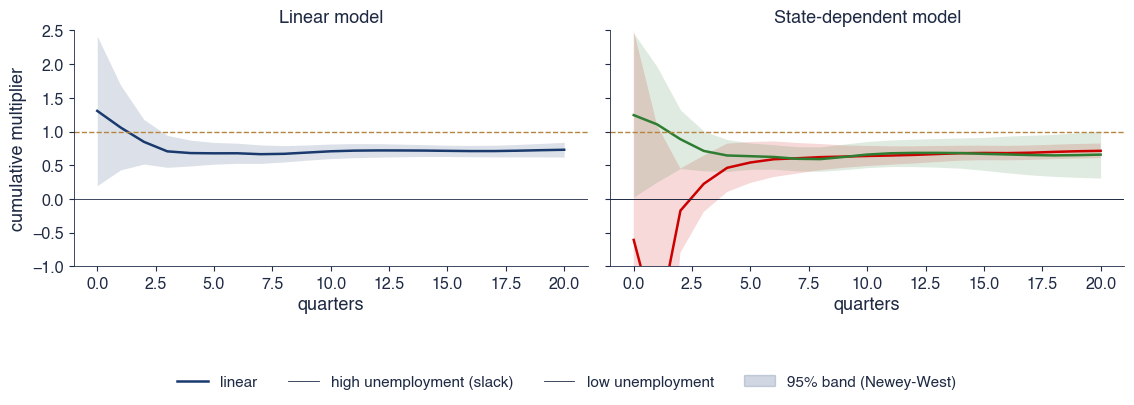

{'lin8': 0.6689611146735857, 'lin8_se': 0.0620161312337331, 'lin16': 0.7096110638620351, 'lin16_se': 0.04301264488602768, 'slack8': 0.6201286651746498, 'slack8_se': 0.09911044011424475, 'slack16': 0.6796508321012429, 'slack16_se': 0.05511709806763983, 'normal8': 0.5906105109937361, 'normal8_se': 0.0926002128391541, 'normal16': 0.6598399792549206, 'normal16_se': 0.1388834447607755, 'share_slack': 0.35912698412698413, 'first': 1889.0, 'last': 2015.75}


In [12]:
def rz_quarterly():
    """Quarterly US data of Ramey and Zubairy (2018), rzdatnew.csv, 1875-2015 (shock and state variables)."""
    d = pd.read_csv(io.BytesIO(zip_member(RAMEY_RZ, 'rzdatnew.csv')))
    return d[d['quarter'] >= RZ['start']].reset_index(drop=True)


def tsls_multi(y, X, Z, W):
    """2SLS with several endogenous regressors X (instruments Z, exogenous W incl. constant); returns beta, Var (NW
    filled later), residuals and the projected design."""
    Zf = np.column_stack([Z, W])
    Xf = np.column_stack([X, W])
    Pz = Zf @ np.linalg.lstsq(Zf, Xf, rcond=None)[0]
    b = np.linalg.lstsq(Pz, y, rcond=None)[0]
    return b, y - Xf @ b, Pz


def rz_frame():
    d = rz_quarterly().copy()
    pot = d['rgdp_pott6']
    d['newsy'] = d['news'] / (pot.shift(1) * d['pgdp'].shift(1))
    d['rgov'] = d['ngov'] / d['pgdp']
    d['y'] = d['rgdp'] / pot
    d['g'] = d['rgov'] / pot
    d['slack'] = (d['unemp'] >= RZ['thr']).astype(float)
    d.loc[d['unemp'].isna(), 'slack'] = np.nan
    return d


def rz_multipliers(d, H=RZ['H']):
    """Cumulative multipliers sum_{j<=h} y_{t+j} / sum_{j<=h} g_{t+j} by LP-IV with the military news shock: linear and
    state dependent (state = slack in t-1), 4 lags of news, y and g (interacted with the state)."""
    p = RZ['p']
    lagc = ['newsy', 'y', 'g']
    s = d['slack'].shift(1)
    Wl = np.column_stack([d[c].shift(j) for c in lagc for j in range(1, p + 1)])
    Wn = np.column_stack([s] + [d[c].shift(j) * s for c in lagc for j in range(1, p + 1)]
                         + [d[c].shift(j) * (1 - s) for c in lagc for j in range(1, p + 1)])
    out = {k: (np.full(H + 1, np.nan), np.full(H + 1, np.nan)) for k in ('lin', 'slack', 'normal')}
    yv, gv = d['y'].values, d['g'].values
    T = len(d)
    for h in range(H + 1):
        cy = np.array([yv[t:t + h + 1].sum() if t + h < T else np.nan for t in range(T)])
        cg = np.array([gv[t:t + h + 1].sum() if t + h < T else np.nan for t in range(T)])
        one = np.ones(T)
        # linear
        D = np.column_stack([cy, cg, d['newsy'], Wl])
        ok = ~np.isnan(D).any(axis=1)
        b, e, Pz = tsls_multi(cy[ok], cg[ok, None], d['newsy'].values[ok, None], np.column_stack([one[ok], Wl[ok]]))
        V = nw_se(Pz, e, h + 1)
        out['lin'][0][h], out['lin'][1][h] = b[0], np.sqrt(V[0, 0])
        # state dependent (joint)
        X = np.column_stack([cg * s, cg * (1 - s)])
        Z = np.column_stack([d['newsy'] * s, d['newsy'] * (1 - s)])
        D = np.column_stack([cy, X, Z, Wn])
        ok = ~np.isnan(D).any(axis=1)
        b, e, Pz = tsls_multi(cy[ok], X[ok], Z[ok], np.column_stack([one[ok], Wn[ok]]))
        V = nw_se(Pz, e, h + 1)
        out['slack'][0][h], out['slack'][1][h] = b[0], np.sqrt(V[0, 0])
        out['normal'][0][h], out['normal'][1][h] = b[1], np.sqrt(V[1, 1])
    return out


def fig_rz(save_it=True):
    """Ramey-Zubairy (2018): cumulative government spending multipliers, linear and by state of slack, 1889-2015."""
    d = rz_frame()
    out = rz_multipliers(d)
    H = RZ['H']
    hh = np.arange(H + 1)
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 3.7), sharey=True)
    b, se = out['lin']
    band_plot(axs[0], hh, b, b - 1.96 * se, b + 1.96 * se, st.MainBlue, 'linear model')
    axs[0].set_title('Linear model')
    for k, c, lab in (('slack', st.IDAred, 'high unemployment (slack)'), ('normal', st.Forest, 'low unemployment')):
        b, se = out[k]
        band_plot(axs[1], hh, b, b - 1.96 * se, b + 1.96 * se, c, lab)
    axs[1].set_title('State-dependent model')
    for ax in axs:
        ax.axhline(1, color=st.Amber, ls='--', lw=1.0)
        ax.set_xlabel('quarters')
        ax.set_ylim(-1.0, 2.5)
    axs[0].set_ylabel('cumulative multiplier')
    st.fig_legend_bottom(fig, [axs[0].lines[0], axs[1].lines[1], axs[1].lines[3], patch(st.MainBlue)],
                         ['linear', 'high unemployment (slack)', 'low unemployment', '95% band (Newey-West)'], ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch3_rz', save_it)
    r = {}
    for k in out:
        for h in (8, 16):
            r[f'{k}{h}'] = float(out[k][0][h])
            r[f'{k}{h}_se'] = float(out[k][1][h])
    r['share_slack'] = float(d['slack'].mean())
    r['first'] = float(d['quarter'].iloc[0])
    r['last'] = float(d['quarter'].iloc[-1])
    return r


print(fig_rz(save_it=False))

## 8. Romania and euro-area spillovers

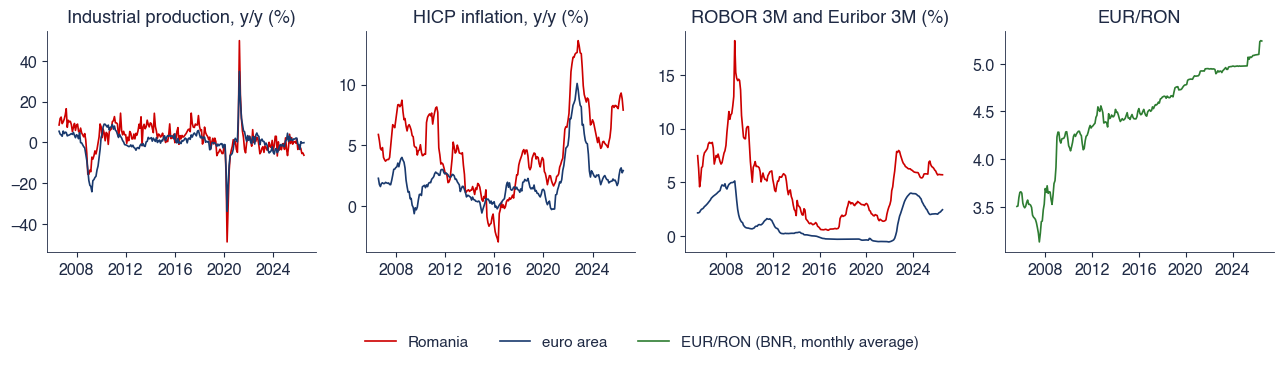

{'first': '2005-08-01', 'last': '2026-07-01', 'n': 252, 'infl_max': 13.618635871407093, 'infl_max_d': '2022-11-01', 'infl_last': 7.890222824037096, 'robor_last': 5.69, 'robor_max': 18.21, 'fx_first': 3.505713043478261, 'fx_last': 5.2377521739130435}


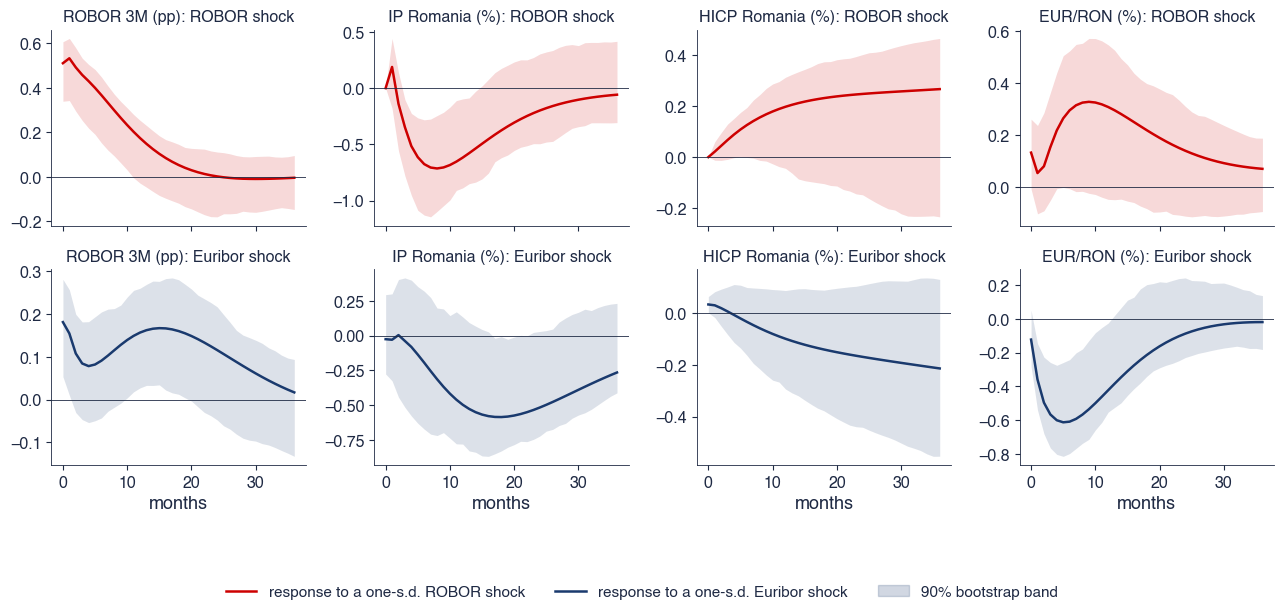

{'T': 250, 'ic': {'aic': 6, 'hq': 2, 'bic': 2}, 'root': 1.0063894311919344}


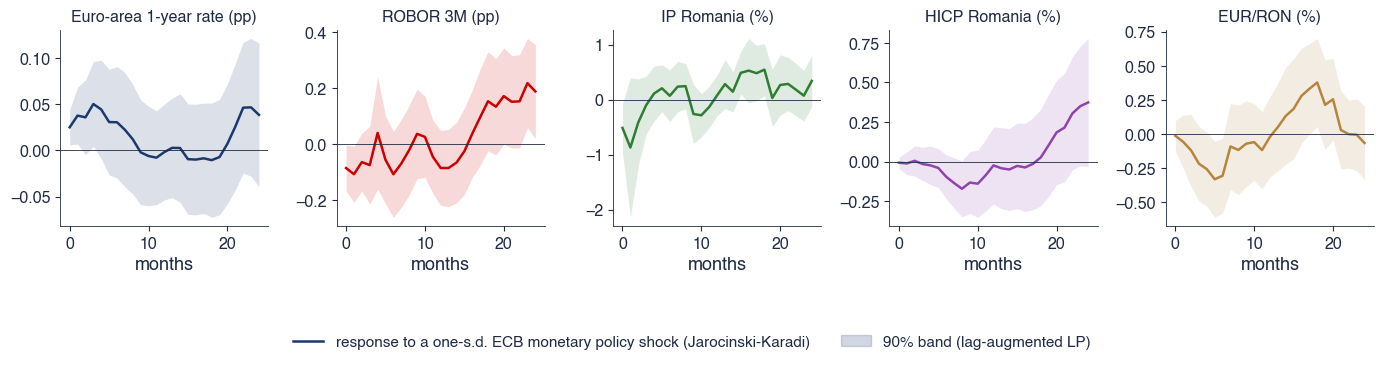

{'sd_bp': 3.1966785423628146, 'n': 243, 'last': '2025-10-01', 'y1_ea0': 0.025046758636935108, 'y1_ea0.se': 0.011473472959197647, 'y1_ea6': 0.030497909905614243, 'y1_ea6.se': 0.03671582423936836, 'y1_ea12': -0.0018475156334390793, 'y1_ea12.se': 0.031540007540635843, 'y1_ea24': 0.03849894979098221, 'y1_ea24.se': 0.04736907204393082, 'y1_ea.nsig': 3, 'r_ro0': -0.08696758423879138, 'r_ro0.se': 0.05015212363073993, 'r_ro6': -0.1092007709943547, 'r_ro6.se': 0.09324085020070229, 'r_ro12': -0.08685764895959618, 'r_ro12.se': 0.08150988889890202, 'r_ro24': 0.18673665081683566, 'r_ro24.se': 0.1018348501438307, 'r_ro.nsig': 4, 'ip_ro0': -0.5154634874613416, 'ip_ro0.se': 0.27038467224112694, 'ip_ro6': 0.06834603458501712, 'ip_ro6.se': 0.28539313848208675, 'ip_ro12': 0.07578348359415432, 'ip_ro12.se': 0.2243270265091215, 'ip_ro24': 0.3381378962787433, 'ip_ro24.se': 0.28131421322254807, 'ip_ro.nsig': 3, 'p_ro0': -0.007389490778288261, 'p_ro0.se': 0.021835651742050093, 'p_ro6': -0.09632713104115664, '

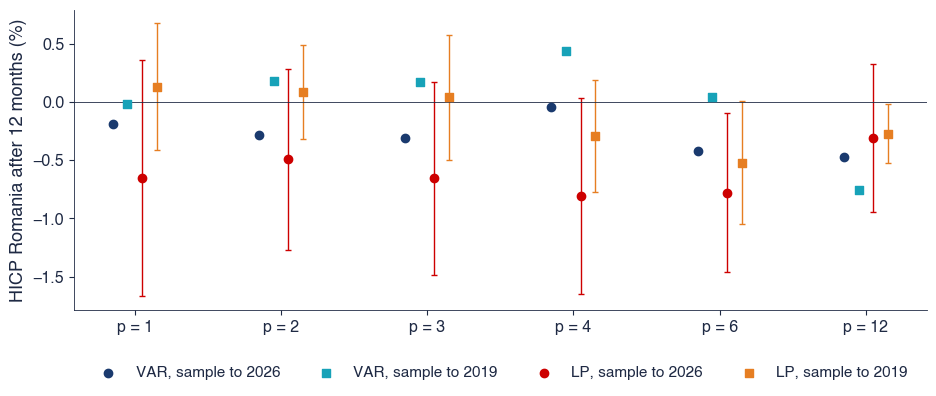

[{'sample': 'to 2026', 'p': 1, 'est': 'VAR', 'b': -0.18763522700322752}, {'sample': 'to 2026', 'p': 1, 'est': 'LP', 'b': -0.6534150746030736, 'se': 0.6178103341662792}, {'sample': 'to 2026', 'p': 2, 'est': 'VAR', 'b': -0.28004573368737895}, {'sample': 'to 2026', 'p': 2, 'est': 'LP', 'b': -0.49300576138571944, 'se': 0.471916330435356}]


In [13]:
def ro_monthly():
    """Romanian and euro-area monthly data, August 2005 onward: log IP (SCA), log HICP, 3-month money-market rates
    (Euribor, ROBOR) and log EUR/RON (monthly average of the BNR reference rate)."""
    def es(k):
        return read_eurostat(*k)
    fx = read_reference_rate('EUR', start='2005-07-01').resample('MS').mean()
    d = pd.concat([100 * np.log(es(EA_IP)), 100 * np.log(es(EA_HICP)), es(EA_R3M), 100 * np.log(es(RO_IP)),
                   100 * np.log(es(RO_HICP)), es(RO_R3M), 100 * np.log(fx)], axis=1,
                  keys=['ip_ea', 'p_ea', 'r_ea', 'ip_ro', 'p_ro', 'r_ro', 'fx'])
    return d.loc[RO_START:RO['end']].dropna()


def month_dummies(idx):
    return np.column_stack([(idx.month == k).astype(float) for k in range(2, 13)])


def ro_model(p=RO['p'], end=RO['end']):
    d = ro_monthly().loc[:end]
    return d, var_ols(d.values, p, exog=month_dummies(d.index))


def lag_ic(Y, exog, pmax=8):
    """AIC, HQ and BIC lag choice on a common sample."""
    T = len(Y) - pmax
    n = Y.shape[1]
    res = {}
    for p in range(1, pmax + 1):
        m = var_ols(Y[pmax - p:], p, exog=exog[pmax - p:])
        ld = np.linalg.slogdet(m['Sigma_ml'])[1]
        k = n * (n * p + 1 + exog.shape[1])
        res[p] = (ld + 2 * k / T, ld + 2 * k * np.log(np.log(T)) / T, ld + k * np.log(T) / T)
    return {c: int(min(res, key=lambda p: res[p][i])) for i, c in enumerate(('aic', 'hq', 'bic'))}


def jk_ecb_shocks():
    """Monthly euro-area monetary policy shocks of Jarocinski and Karadi (2020), updated by the authors (public CSV):
    MP_pm = pure monetary policy shock (poor man's sign restrictions), CBI_pm = central bank information shock."""
    d = pd.read_csv(io.BytesIO(get_bytes(JK_ECB)))
    d.index = pd.to_datetime(dict(year=d['year'], month=d['month'], day=1))
    return d[['MP_pm', 'CBI_pm', 'pc1_hf']]


def ro_lp_frame():
    """Romanian data, the euro-area 1-year spot rate (ECB yield curve, AAA, monthly average) and the shock."""
    d = ro_monthly()
    y1 = read_ecb(*EA_Y1).resample('MS').mean()
    s = jk_ecb_shocks()['MP_pm']
    return d.join(y1.rename('y1_ea'), how='left').join(s.rename('mp'), how='left')


def ro_lp(d, H=24, p=2, end='2025-10-01', scale=None):
    """LP of Romanian and euro-area variables on the Jarocinski-Karadi monetary policy shock: p + 1 lags of all
    variables and of the shock (lag augmentation), month dummies, Eicker-Huber-White standard errors."""
    dd = d.loc[:end] if end else d
    sc = scale or float(dd['mp'].std())
    W = np.column_stack([lags_of(dd, RO_VARS + ['y1_ea', 'mp'], p + 1), month_dummies(dd.index)])
    out = {}
    full = d
    for v in ['y1_ea', 'r_ro', 'ip_ro', 'p_ro', 'fx']:
        bs, ses = [], []
        for h in range(H + 1):
            y = full[v].shift(-h).loc[dd.index].values
            b, se = lp(y, dd['mp'].values, W, 0, lag_aug=True)
            bs.append(b[0] * sc)
            ses.append(se[0] * sc)
        out[v] = (np.array(bs), np.array(ses))
    return out, sc


def fig_ro_data(save_it=True):
    """Romanian and euro-area data: annual growth of IP, HICP inflation, money-market rates, EUR/RON."""
    d = ro_monthly()
    fig, axs = plt.subplots(1, 4, figsize=(13, 3.3))
    axs[0].plot(d.index, d['ip_ro'].diff(12), color=st.IDAred, lw=1.2, label='Romania')
    axs[0].plot(d.index, d['ip_ea'].diff(12), color=st.MainBlue, lw=1.2, label='euro area')
    axs[0].set_title('Industrial production, y/y (%)')
    axs[1].plot(d.index, d['p_ro'].diff(12), color=st.IDAred, lw=1.2, label='_r')
    axs[1].plot(d.index, d['p_ea'].diff(12), color=st.MainBlue, lw=1.2, label='_e')
    axs[1].set_title('HICP inflation, y/y (%)')
    axs[2].plot(d.index, d['r_ro'], color=st.IDAred, lw=1.2, label='_r')
    axs[2].plot(d.index, d['r_ea'], color=st.MainBlue, lw=1.2, label='_e')
    axs[2].set_title('ROBOR 3M and Euribor 3M (%)')
    axs[3].plot(d.index, np.exp(d['fx'] / 100), color=st.Forest, lw=1.2, label='EUR/RON (BNR, monthly average)')
    axs[3].set_title('EUR/RON')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch3_ro_data', save_it)
    return dict(first=str(d.index[0].date()), last=str(d.index[-1].date()), n=int(len(d)),
                infl_max=float(d['p_ro'].diff(12).max()), infl_max_d=str(d['p_ro'].diff(12).idxmax().date()),
                infl_last=float(d['p_ro'].diff(12).iloc[-1]), robor_last=float(d['r_ro'].iloc[-1]),
                robor_max=float(d['r_ro'].max()), fx_first=float(np.exp(d['fx'].iloc[0] / 100)),
                fx_last=float(np.exp(d['fx'].iloc[-1] / 100)))


def fig_ro_var(save_it=True, B=NBOOT):
    """Romanian VAR(2) in levels: responses to a domestic money-market rate shock (ROBOR) and to a euro-area rate shock
    (Euribor), Cholesky with the euro-area block first; 90% residual-bootstrap bands."""
    d, m = ro_model()
    H = RO['H']
    ic = lag_ic(d.values, month_dummies(d.index))
    th = irf(m['A'], np.linalg.cholesky(m['Sigma']), H)
    draws, _ = bootstrap_var(m, chol, H, B=B)
    lo, hi = bands(draws, (0.05, 0.95))
    v = RO_VARS
    resp = [('r_ro', 'ROBOR 3M (pp)'), ('ip_ro', 'IP Romania (%)'), ('p_ro', 'HICP Romania (%)'), ('fx', 'EUR/RON (%)')]
    fig, axs = plt.subplots(2, 4, figsize=(13, 5.8), sharex=True)
    hh = np.arange(H + 1)
    for row, (sk, slab) in enumerate((('r_ro', 'ROBOR shock'), ('r_ea', 'Euribor shock'))):
        k = v.index(sk)
        for col, (rv, rlab) in enumerate(resp):
            i = v.index(rv)
            band_plot(axs[row, col], hh, th[:, i, k], lo[:, i, k], hi[:, i, k], [st.IDAred, st.MainBlue][row], slab)
            axs[row, col].set_title(f'{rlab}: {slab}', fontsize=11.5)
            if row == 1:
                axs[row, col].set_xlabel('months')
    st.fig_legend_bottom(fig, [axs[0, 0].lines[0], axs[1, 0].lines[0], patch(st.MainBlue)],
                         ['response to a one-s.d. ROBOR shock', 'response to a one-s.d. Euribor shock',
                          '90% bootstrap band'], ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch3_ro_var', save_it)
    fe = fevd(th)
    k_ro, k_ea = v.index('r_ro'), v.index('r_ea')
    ip, pr, fx = v.index('ip_ro'), v.index('p_ro'), v.index('fx')
    r = dict(T=int(len(m['U'])), ic=ic, root=max_root(m['A']), B=B,
             sd_ro=float(th[0, k_ro, k_ro]), sd_ea=float(th[0, k_ea, k_ea]))
    for tag, k in (('ro', k_ro), ('ea', k_ea)):
        for name, i in (('ip', ip), ('p', pr), ('fx', fx), ('r', k_ro)):
            for h in (12, 24):
                r[f'{tag}.{name}{h}'] = float(th[h, i, k])
                r[f'{tag}.{name}{h}.lo'] = float(lo[h, i, k])
                r[f'{tag}.{name}{h}.hi'] = float(hi[h, i, k])
    for name, i in (('ip', ip), ('p', pr), ('fx', fx), ('r', k_ro)):
        for h in (12, 36):
            r[f'fevd.{name}{h}.ea'] = float(fe[h, i, :3].sum())
            r[f'fevd.{name}{h}.own'] = float(fe[h, i, i])
            r[f'fevd.{name}{h}.r_ro'] = float(fe[h, i, k_ro])
    return r


def fig_ro_lp(save_it=True):
    """Euro-area monetary policy spillovers to Romania: lag-augmented LP on the Jarocinski-Karadi shock (one s.d.)."""
    d = ro_lp_frame()
    out, sc = ro_lp(d)
    H = 24
    hh = np.arange(H + 1)
    titles = {'y1_ea': 'Euro-area 1-year rate (pp)', 'r_ro': 'ROBOR 3M (pp)', 'ip_ro': 'IP Romania (%)', 'p_ro': 'HICP Romania (%)',
              'fx': 'EUR/RON (%)'}
    fig, axs = plt.subplots(1, 5, figsize=(14, 3.3))
    for ax, (v, c) in zip(axs, zip(titles, [st.MainBlue, st.IDAred, st.Forest, st.Purple, st.Amber])):
        b, se = out[v]
        band_plot(ax, hh, b, b - 1.645 * se, b + 1.645 * se, c, 'LP')
        ax.set_title(titles[v], fontsize=11.5)
        ax.set_xlabel('months')
    st.fig_legend_bottom(fig, [axs[0].lines[0], patch(st.MainBlue)],
                         ['response to a one-s.d. ECB monetary policy shock (Jarocinski-Karadi)', '90% band (lag-augmented LP)'],
                         ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.09, 1, 1))
    save('ats_ch3_ro_lp', save_it)
    r = dict(sd_bp=float(100 * sc), n=int(d.loc[:'2025-10-01'].shape[0]), last='2025-10-01')
    for v in out:
        b, se = out[v]
        for h in (0, 6, 12, 24):
            r[f'{v}{h}'] = float(b[h])
            r[f'{v}{h}.se'] = float(se[h])
        r[f'{v}.nsig'] = int((np.abs(b / se) > 1.645).sum())
    for h in (0, 1, 2):
        r[f'F{h}'] = float((out['y1_ea'][0][h] / out['y1_ea'][1][h]) ** 2)
    return r


def fig_ai_case(save_it=True):
    """Robustness of one number: the response of Romanian HICP after 12 months to a euro-area rate shock, across lag
    lengths, samples and estimators (VAR with Cholesky; recursive LP with the same ordering), per 25 bp of Euribor."""
    rows = []
    for end, lab in ((RO['end'], 'to 2026'), ('2019-12-01', 'to 2019')):
        for p in (1, 2, 3, 4, 6, 12):
            d, m = ro_model(p=p, end=end)
            B0 = np.linalg.cholesky(m['Sigma'])
            th = irf(m['A'], B0, 12)
            k, i = RO_VARS.index('r_ea'), RO_VARS.index('p_ro')
            rows.append(dict(sample=lab, p=p, est='VAR', b=float(th[12, i, k] / th[0, k, k] * 0.25)))
            # LP: p_ro_{t+12} on the Euribor residual-type regressor: r_ea_t controlling for lags and the
            # contemporaneous euro-area block ordered before it (recursive LP, Plagborg-Moller and Wolf 2021)
            W = np.column_stack([lags_of(d, RO_VARS, p), d[['ip_ea', 'p_ea']].values, month_dummies(d.index)])
            y = d['p_ro'].shift(-12).values
            Xo = np.column_stack([d['r_ea'].values, np.ones(len(d)), W])
            ok = ~np.isnan(np.column_stack([y, Xo])).any(axis=1)
            bb = np.linalg.lstsq(Xo[ok], y[ok], rcond=None)[0]
            se = np.sqrt(nw_se(Xo[ok], y[ok] - Xo[ok] @ bb, 13)[0, 0])
            rows.append(dict(sample=lab, p=p, est='LP', b=float(bb[0] * 0.25), se=float(se * 0.25)))
    t = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(11, 3.9))
    xs = {p: i for i, p in enumerate((1, 2, 3, 4, 6, 12))}
    for (lab, est), c, mk, off in ((('to 2026', 'VAR'), st.MainBlue, 'o', -0.15), (('to 2019', 'VAR'), st.Teal, 's', -0.05),
                                   (('to 2026', 'LP'), st.IDAred, 'o', 0.05), (('to 2019', 'LP'), st.Orange, 's', 0.15)):
        s = t[(t['sample'] == lab) & (t['est'] == est)]
        x = np.array([xs[p] for p in s['p']]) + off
        ax.scatter(x, s['b'], color=c, marker=mk, s=36, zorder=3, label=f'{est}, sample {lab}')
        if est == 'LP':
            ax.errorbar(x, s['b'], yerr=1.645 * s['se'], fmt='none', ecolor=c, elinewidth=1, capsize=2)
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xticks(list(xs.values()))
    ax.set_xticklabels([f'p = {p}' for p in xs])
    ax.set_ylabel('HICP Romania after 12 months (%)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.14)
    save('ats_ch3_ai_case', save_it)
    return dict(rows=rows, vmin=float(t['b'].min()), vmax=float(t['b'].max()),
                n_pos=int((t['b'] > 0).sum()), n=int(len(t)))


print(fig_ro_data(save_it=False))
r = fig_ro_var(save_it=False, B=200)
print({k: r[k] for k in ('T', 'ic', 'root')})
print(fig_ro_lp(save_it=False))
print(fig_ai_case(save_it=False)['rows'][:4])

## Exercises

1. Order the funds rate first in the CEE VAR: which responses change, and why?
2. Add the 1-year yield to the Romanian VAR as a euro-area policy indicator and compare the Euribor responses.
3. Replace the 25 bp normalisation of the proxy SVAR by a one-standard-deviation shock using $b_1'\Sigma_u^{-1}b_1 = 1$.